<a href="https://colab.research.google.com/github/orsikrebsi/orsikrebsi/blob/main/oriane_w3_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Homework

In this homework assignment we shift from basic synthetic data generation to advanced model tuning, privacy integration, and comprehensive auditing. You will implement Differentially Private (DP) models, explore "Naive-Bayes" inspired hyperparameter search, and perform a full suite of audits—Fidelity, Privacy, Utility, and Fairness—across multiple synthetic generators.

### **Session Overview**

* **DPCTGAN & TVAE Implementation:** Integrate privacy-preserving and Variational Autoencoder-based synthesizers into your workflow.
* **Sequential Hyperparameter Search:** Move beyond random search with a custom "Bayesian-ish" strategy that learns from previous trial results.
* **Multi-Model Privacy-Utility Tradeoff:** Quantify how increasing privacy protection (lowering epsilon) impacts the model's ability to catch fraud.
* **The 4-Pillar Audit:** Run standardized tests for Fidelity, Privacy, Utility, and Fairness across CTGAN, PrivBayes, DPCTGAN, and TVAE.

### **Learning Objectives**

* **Configure Privacy Knobs:** Learn to balance `epsilon`, `delta`, and `sigma` to generate data that is both private and useful.
* **Implement Sequential Tuning:** Build an intelligent search loop that identifies "good" hyperparameter values and samples new trials near them.
* **Develop Reusable Workflows:** Encapsulate complex training and sampling logic into modular Python classes for consistent experimentation.
* **Perform Multi-Dimensional Auditing:** Evaluate synthetic datasets through a unified lens of statistical similarity, membership risk, and subgroup fairness.

### **IMPORTANT NOTE:**

**This notebook will not run as a standalone file. You must replicate the Session 1 workflow (for DPCTGAN and TVAE) and the Session 2 workflow (for Hyperparameter Tuning), replacing the original training and search blocks with the specialized snippets provided below.**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install "sdv==1.17.0" "smartnoise-synth" "opacus"
!pip uninstall -y numpy smartnoise-synth >/dev/null 2>&1
!pip install -U --force-reinstall "numpy==2.0.2" "smartnoise-synth==1.0.6"

print("\n✅ SDV installed safely.")
print("CRITICAL: Click 'Runtime' -> 'Restart session' now.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.7 MB/s eta 0:00:00

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.3 MB/s eta 0:00:00
  Using cached faker-40.15.0-py3-none-any.whl.metadata (16 kB)
  Using cached opacus-0.14.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached pac_synth-0.0.8-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.4 kB)
  Using cached smartnoise_sql-1.0.10-py3-none-any.whl.metadata (9.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached opendp-0.14.2-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (6.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.8 MB/s eta 0:00:00
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.3 MB/s eta 0:00:00
Using cached faker-


✅ SDV installed safely.
CRITICAL: Click 'Runtime' -> 'Restart session' now.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
from importlib.metadata import version

print("numpy:", np.__version__)                    # should be 2.0.2
print("smartnoise-synth:", version("smartnoise-synth"))  # should be 1.0.6

from snsynth.pytorch.nn import DPCTGAN
print("✅ DPCTGAN OK")

numpy: 2.0.2
smartnoise-synth: 1.0.6
✅ DPCTGAN OK


In [3]:
from pathlib import Path
from google.colab import userdata
import yaml

try:
    # Attempt to get path from Colab Secrets
    config_path = userdata.get('PROJECT_CONFIG_PATH')
except:
    # Fallback or prompt user if secret isn't set
    config_path = input("Please enter the path to your config file: ")

with open(config_path, 'r') as f:
    _CONFIG = yaml.safe_load(f)

BASE_PATH = Path(_CONFIG["BASE_PATH"])
SRC_EDITABLE_INSTALL_PATH = Path(_CONFIG["SRC_EDITABLE_INSTALL_PATH"])
SYN_DATA_DIR = Path(_CONFIG["SYN_DATA_DIR"])
RANDOM_SEED = _CONFIG["RANDOM_SEED"]

base_path = BASE_PATH
print("base_path:", base_path)
print("exists?  ", base_path.exists())

print("✅ Config loaded. SRC path exists:", SRC_EDITABLE_INSTALL_PATH.exists())

base_path: /content/drive/MyDrive/MASAID/AI_Project_Course/SynthDataFraudwerk/repo
exists?   True
✅ Config loaded. SRC path exists: True


In [4]:
# 1. Install your local project in editable mode
!pip -q install -e {SRC_EDITABLE_INSTALL_PATH}

# 2. Refresh site packages
import site
for sp in site.getsitepackages():
    site.addsitedir(sp)

import sdv
import numpy as np
import importlib

print(f"✅ Development environment ready.")
print(f"Using NumPy: {np.__version__}")
print(f"Using SDV: {sdv.__version__}")

# --- THE WORKAROUND FOR AUTORELOAD ---
# Whenever you edit a file in your 'credit_fraud_synth' folder,
# just run this block to manually reload that specific module:
#
# import credit_fraud_synth.your_module
# importlib.reload(credit_fraud_synth.your_module)

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for credit-fraud-synth (pyproject.toml) ... done
✅ Development environment ready.
Using NumPy: 2.0.2
Using SDV: 1.17.0


In [5]:
# --- Setup: imports, utility functions, and SDV CTGAN ---

# Core data handling
from dataclasses import dataclass
import math
import os
from pathlib import Path
import re
import sys
import time
from typing import Any, Dict, Iterable, Optional, Sequence, Tuple
import warnings
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import torch
from IPython import get_ipython
from IPython.core.magic import register_cell_magic
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

np.random.seed(RANDOM_SEED)
RNG = np.random.default_rng(RANDOM_SEED)

# PyTorch reproducibility
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Hardware check
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Imports loaded. PyTorch using device: {device.upper()}")

warnings.filterwarnings("ignore", category=RuntimeWarning)


✅ Imports loaded. PyTorch using device: CUDA


# Runtime instrumentation

In [6]:
@register_cell_magic
def resource_usage(line, cell):
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / 1e6
    cpu_before = process.cpu_times()

    ip = get_ipython()
    t0 = time.time()
    if ip is None:
        exec(cell, globals())
    else:
        ip.run_cell_magic('time', '', cell)
    elapsed = time.time() - t0

    mem_after = process.memory_info().rss / 1e6
    cpu_after = process.cpu_times()

    print(f"\nWall time (resource tracker): {elapsed:.3f} sec")
    print(f"Memory change: {mem_after - mem_before:.3f} MB")
    print(f"User CPU change: {cpu_after.user - cpu_before.user:.3f} sec")
    print(f"System CPU change: {cpu_after.system - cpu_before.system:.3f} sec")

print("Resource-usage magic ready: use %%resource_usage to log compute cost.")


Resource-usage magic ready: use %%resource_usage to log compute cost.


In [7]:
#MEASURING RUNTIME: TIME

%%time
# Example: simple vectorised operation timed with built-in magic
_ = np.random.rand(200000).sum()

CPU times: user 4.18 ms, sys: 20 µs, total: 4.2 ms
Wall time: 3.94 ms


In [8]:
#MEASURING RUNTIME: RESOURCE USAGE
%%resource_usage
# Same operation instrumented with the resource-usage magic
_ = np.random.rand(200000).sum()

CPU times: user 2.93 ms, sys: 0 ns, total: 2.93 ms
Wall time: 2.94 ms

Wall time (resource tracker): 0.003 sec
Memory change: 0.000 MB
User CPU change: 0.000 sec
System CPU change: 0.000 sec


In [9]:

import importlib
import credit_fraud_synth
import credit_fraud_synth.data
import credit_fraud_synth.data.utils

from credit_fraud_synth.data.loader import load_raw_data as load_from_folder
from credit_fraud_synth.data.utils import (
    score_gan_cfg,
    build_core_gan_cfg,
    extract_ctgan_training_logs,
    prepare_ctgan_fit_dataframe,
    prepare_full_df,
    preprocess_for_gan,
    reconstruct_people_and_transactions,
    save_synthetic_datasets,
)






✅ All Search Helpers and Scorer defined successfully.


In [10]:
# Extract path from config
target_path = Path(_CONFIG["PROCESSED_DATA_DIR"])

print(f"Directory path from config: {target_path}")
print(f"Is it a directory? {target_path.is_dir()}")

# Check for the actual files
p_file = target_path / "profiles.csv"
t_file = target_path / "transactions.csv"

print(f"Profiles file path: {p_file}")
print(f"Does profiles.csv exist? {p_file.exists()}")
print(f"Is profiles.csv actually a directory? {p_file.is_dir()}")

Directory path from config: /content/drive/MyDrive/MASAID/AI_Project_Course/SynthDataFraudwerk/repo/data/processed
Is it a directory? True
Profiles file path: /content/drive/MyDrive/MASAID/AI_Project_Course/SynthDataFraudwerk/repo/data/processed/profiles.csv
Does profiles.csv exist? True
Is profiles.csv actually a directory? False


In [11]:
# -----------------------------------------------------------------------------
# TODO : Load  CSV files
#       Point `PROCESSED_DATA_DIR` (or `base_path`) to the folder containing the processed `profiles.csv`
#       and `transactions.csv`, then load them into DataFrames using the
#       `load_data` function defined in the `credit_fraud_synth` package.
# -----------------------------------------------------------------------------
PROCESSED_DATA_DIR = Path(_CONFIG["PROCESSED_DATA_DIR"])

profiles_df, transactions_df = load_from_folder(PROCESSED_DATA_DIR)

print("profiles_df shape:", profiles_df.shape)
print("transactions_df shape:",transactions_df.shape)

display(profiles_df.head(3))
display(transactions_df.head(3))

# Merging the two dataframes on the `profile_id` column to create a full dataframe

full_df = transactions_df.merge(profiles_df, on="profile_id", how="left")
full_df.head()



profiles_df shape: (5000, 13)
transactions_df shape: (88194, 10)


,profile_id,SEX,RAC1P,NATIVITY,MAR,ESR,WKHP,HICOV,DIS,DIVISION,age_group,income_group,education_level
0,0,1,1,1,2,6.0,40,2,2,5,2,4,4
1,1,1,1,1,3,6.0,40,1,1,1,3,4,4
2,2,1,2,1,5,6.0,40,2,2,7,1,4,3


,profile_id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,timestamp
0,2440,25.508471,0.060404,3.192306,1,0,0,1,0,2025-02-13 00:11:22.618101
1,4966,5.178768,0.388229,1.024371,1,0,0,1,0,2025-02-13 01:08:06.190955
2,1129,2.126046,0.584223,2.018877,1,0,0,1,0,2025-02-13 01:29:53.005209


,profile_id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud,timestamp,...,NATIVITY,MAR,ESR,WKHP,HICOV,DIS,DIVISION,age_group,income_group,education_level
0,2440,25.508471,0.060404,3.192306,1,0,0,1,0,2025-02-13 00:11:22.618101,...,1,2,6.0,0,1,1,5,4,4,2
1,4966,5.178768,0.388229,1.024371,1,0,0,1,0,2025-02-13 01:08:06.190955,...,1,1,6.0,0,1,2,2,2,0,1
2,1129,2.126046,0.584223,2.018877,1,0,0,1,0,2025-02-13 01:29:53.005209,...,1,5,6.0,0,1,1,5,3,4,2
3,3206,30.341823,55.114392,1.600864,1,0,0,1,1,2025-02-13 01:38:52.628739,...,1,5,6.0,0,2,2,3,1,0,1
4,3008,141.051705,4.316694,1.476942,1,1,0,0,0,2025-02-13 01:47:47.322988,...,1,3,6.0,0,2,2,5,3,0,2


# Balance the dataset by oversampling minority fraud cases while keeping Pandas column names intact for DPCTGAN

In [12]:
def balance_dataframe_for_gan(df: pd.DataFrame, target_fraud_ratio: float = 0.3) -> pd.DataFrame:
    """Balances a DataFrame by oversampling the minority fraud class."""

    # 1. Split the data into normal and fraud piles
    df_fraud = df[df['fraud'] == 1]
    df_nonfraud = df[df['fraud'] == 0]

    n_nonfraud = len(df_nonfraud)

    # 2. Calculate how many fraud rows we need to hit our 30% target
    n_fraud_target = int((target_fraud_ratio / (1.0 - target_fraud_ratio)) * n_nonfraud)

    # 3. Oversample (copy-paste) the fraud rows until we hit the target
    # 'replace=True' allows Pandas to pick the same row multiple times
    df_fraud_balanced = df_fraud.sample(n=n_fraud_target, replace=True, random_state=42)

    # 4. Stack them back together and shuffle the deck
    df_balanced = pd.concat([df_nonfraud, df_fraud_balanced]).sample(frac=1, random_state=42).reset_index(drop=True)

    fraud_share = len(df_fraud_balanced) / len(df_balanced)
    print(f"Balanced DataFrame shape: {df_balanced.shape}")
    print(f"Approx. fraud share during training: {fraud_share:.1%}")

    return df_balanced

# creating subset
train_df_subset = balance_dataframe_for_gan(full_df, target_fraud_ratio=0.3)

Balanced DataFrame shape: (113430, 22)
Approx. fraud share during training: 30.0%


### Task 1.1 — Configuring DPCTGAN

To initialize the **DPCTGAN Trainer**, we define hyperparameters that control (1) the neural network capacity, (2) the training dynamics, and (3) the **differential privacy (DP)** budget + noise injection. These settings determine training stability and the privacy/utility tradeoff.

### Parameters & Definitions

#### Core CTGAN hyperparameters

* **`embedding_dim`**: Size of the learned embedding vectors for **categorical** columns (internal representation for category tokens).
* **`generator_dim` / `discriminator_dim`**: Tuple of hidden-layer widths for Generator/Discriminator MLPs (e.g., `(64, 64)` means two hidden layers with 64 units each).
* **`batch_size`**: Number of rows per minibatch update.
* **`epochs`**: Number of full passes over the training data.
* **`generator_lr` / `discriminator_lr`**: Learning rates (typically Adam). Higher can train faster but destabilize adversarial training.
* **`discriminator_steps`**: How many discriminator updates happen per generator update.
* **`pac`**: “Packed” discriminator input size (groups `pac` samples together) to reduce **mode collapse**; should divide `batch_size`.

---

### Differential Privacy (DP) knobs

* **`use_dp`**: Turns DP training **on/off**.
* **`epsilon` (`ε`)**: Privacy budget (smaller = more private, usually lower utility).
* **`delta` (`δ`)**: Failure probability (commonly something like `1e-5` or `< 1/N`).
* **`sigma`**: Noise multiplier / std factor used for DP noise (higher = more noise = more privacy, less utility).
* **`max_per_sample_grad_norm`**: Clipping threshold for per-example gradients before adding noise (lower = more clipping = more stability/privacy, can hurt utility).
* **`preprocessor_eps`**: Privacy budget reserved for any **DP preprocessing** step (e.g., privatized metadata/statistics). (How it’s used depends on the SmartNoise implementation details.)
* **`loss_type_choice`**: Which GAN loss is used:

  * **`"cross_entropy"`**: classic GAN-style discriminator loss
  * **`"wasserstein"`**: WGAN-style loss (often more stable, but depends on the specific implementation)

---

### Configuration Summary

| Category                 | Parameters                                                                            |
| ------------------------ | ------------------------------------------------------------------------------------- |
| **Model Capacity**       | `embedding_dim`, `generator_dim`, `discriminator_dim`                                 |
| **Training Flow**        | `batch_size`, `epochs`, `discriminator_steps`                                         |
| **Optimization**         | `generator_lr`, `discriminator_lr`                                                    |
| **Diversity Control**    | `pac`                                                                                 |
| **Runtime**              | `verbose`, `cuda`                                                                     |
| **Differential Privacy** | `use_dp`, `epsilon`, `delta`, `sigma`, `max_per_sample_grad_norm`, `preprocessor_eps` |
| **Loss Type**            | `loss_type_choice`, `loss_type_options`                                               |


In [13]:
# Set the architectural dimensions for the embedding, generator, and discriminator networks.
# DONE
embedding_dim = 32
generator_dim = (64, 64)
discriminator_dim = (64, 64)

# Define training hyperparameters including batch size, epoch count, learning rates, and discriminator update frequency.
# DONE
batch_size = 128 #tried with 512, results were worse (better per-step gradient estimate, but far fewer updates per epoch, so less optimization)
epochs = 500
generator_lr = 2e-4
discriminator_lr = 1e-4
discriminator_steps = 1

# Set the PAC value to control the number of samples grouped together for the discriminator. tells the Discriminator to look at a group of samples instead of just one at a time.
# DONE
pac = 16

# Configure runtime settings for logging verbosity and hardware acceleration.
# DONE
verbose = True
cuda = True #tells the model to run on the GPU instead of the CPU.This saves a massive amount of trianing time.

####################################
# NB: we dropped enforce_min_max_values that we used in the GAN because in a DP context this would be a
#privacy violation --> if an attacker knows the exact max or minimum trx amount, they might be able to
# identify the individual behind it.
####################################

# Define Differential Privacy (DP) parameters including epsilon, delta, noise multiplier (sigma), and gradient clipping norms.
# DONE
use_dp = True
epsilon = 3.0    # The privacy budget. 3.0 is a standard middle-ground (usually 1.0 to 10.0).
delta = 1e-5     # Failure probability. Rule of thumb: should be less than (1 / size_of_dataset).
sigma = 1.0      # Noise multiplier. 1.0 is a standard starting point for DP-SGD.
max_per_sample_grad_norm = 1.0 # Clipping threshold. 1.0 prevents extreme outliers from pulling the model.
preprocessor_eps = 0.3      # Budget spent on privatizing metadata (like estimating min/max safely).

# Select the loss function type (cross_entropy or wasserstein) for the DPCTGAN optimization process.
# DONE
loss_type_options = ["cross_entropy", "wasserstein"]
loss_type_choice = "wasserstein" # Wasserstein often provides more stable training for GANs than cross-entropy.

Changed sigma from 1.0 to 1.5

# TESTS

_ Checked with same hyperparameters, just changed the epochs to 500.
_ The training stopped at 110 epochs after hitting the privacy budget (around 1 spent for preprocessing, 2 left for training).

New trial should proceed with:

- less preprocessor: 0.3 instead of 1,
- lr of the discriminator reestablished at the smae level than the generator, since the discrepancy between their performance was too wide.





Modification based on results --> discriminator's learning decreased

# 1. discriminator's learning rate decreased (half as fast as the generator)
generator_lr = 2e-4
discriminator_lr = 1e-4  # Dropped from 2e-4

# 2. Batch size increased to give the Generator more examples to study at once
batch_size = 128  # Increased from 64

# 3.  PAC size increased to force the Discriminator to demand more diversity
pac = 16  # Increased from 8 (Must cleanly divide the batch_size: 128 / 16 = 8 packs)

# 4. not changed
embedding_dim = 32
generator_dim = (64, 64)
discriminator_dim = (64, 64)
discriminator_steps = 1
epochs = 30
use_dp = True
epsilon = 3.0

In [14]:
# Consolidate all architectural, training, and differential privacy settings into a single configuration dictionary.
# DONE
gan_hyperparams = {
    "embedding_dim": embedding_dim,
    "generator_dim": generator_dim,
    "discriminator_dim": discriminator_dim,
    "batch_size": batch_size,
    "epochs": epochs,
    "generator_lr": generator_lr,
    "discriminator_lr": discriminator_lr,
    "discriminator_steps": discriminator_steps,
    "pac": pac,
    "verbose": verbose,
    "cuda": cuda,
    "disabled_dp": (not use_dp),
    "epsilon": epsilon,
    "delta": delta,
    "sigma": sigma,
    "max_per_sample_grad_norm": max_per_sample_grad_norm,
    "preprocessor_eps": preprocessor_eps,
    "loss": loss_type_choice,
}

# Print a confirmation message and display the final hyperparameter dictionary to verify the configuration.
print("✅ DPCTGAN config set.")
print(gan_hyperparams)

print(f"   epochs={epochs}, discriminator_steps={discriminator_steps} (int), "
      f"epsilon={epsilon}, preprocessor_eps={preprocessor_eps}")
print(gan_hyperparams)

# Sanity assertions — fail loudly if anyone re-introduces the bug
assert isinstance(discriminator_steps, int) and discriminator_steps >= 1, \
    "discriminator_steps must be a positive integer"
assert batch_size % pac == 0, f"batch_size ({batch_size}) must be divisible by pac ({pac})"


✅ DPCTGAN config set.
{'embedding_dim': 32, 'generator_dim': (64, 64), 'discriminator_dim': (64, 64), 'batch_size': 128, 'epochs': 500, 'generator_lr': 0.0002, 'discriminator_lr': 0.0001, 'discriminator_steps': 1, 'pac': 16, 'verbose': True, 'cuda': True, 'disabled_dp': False, 'epsilon': 3.0, 'delta': 1e-05, 'sigma': 1.0, 'max_per_sample_grad_norm': 1.0, 'preprocessor_eps': 0.3, 'loss': 'wasserstein'}
   epochs=500, discriminator_steps=1 (int), epsilon=3.0, preprocessor_eps=0.3
{'embedding_dim': 32, 'generator_dim': (64, 64), 'discriminator_dim': (64, 64), 'batch_size': 128, 'epochs': 500, 'generator_lr': 0.0002, 'discriminator_lr': 0.0001, 'discriminator_steps': 1, 'pac': 16, 'verbose': True, 'cuda': True, 'disabled_dp': False, 'epsilon': 3.0, 'delta': 1e-05, 'sigma': 1.0, 'max_per_sample_grad_norm': 1.0, 'preprocessor_eps': 0.3, 'loss': 'wasserstein'}


### **Task 1.2: Training DPCTGAN and Row Generation**

**Description**
We implement a robust training function that integrates Differentially Private (DP) constraints into the CTGAN architecture. This ensures the synthetic records preserve overall data patterns while mathematically preventing the re-identification of specific individuals.

**Plan**

* **Sanitize Data:** Use `df.replace()` and `df.fillna()` within `fit_generate_dpctgan` to handle infinities and missing values via median/mode imputation.
* **Fit DPCTGAN:** Initialize the `DPCTGAN` estimator and call `synth.fit()` on the dataset, passing `categorical_columns` and `preprocessor_eps`.
* **Sample and Post-process:** Generate synthetic records using `synth.sample()` and use `pd.to_numeric()` to cast the generated strings back to their original numeric schemas.
* **Log Diagnostics:** Extract training metrics such as `loss_g_list` and `epsilon_list` to track model convergence and privacy budget consumption.


# ORIGINAL CELL --> deleted & replaced with the one below.

The Metadata Trap: AI deleted the metadata = SingleTableMetadata() block. That belongs to the standard SDV library. DPCTGAN crashes if you give it metadata; it strictly wants a list of categorical column names.

The SDV Library Update: The sdv library recently went through a massive, fundamental overhaul (moving to version 1.0+). In this new version, they force everyone to use that SingleTableMetadata() object to describe the dataset.

The DPCTGAN Wrapper: DPCTGAN (especially the SmartNoise implementation) is usually built on the older architecture of SDV. The older architecture doesn't know what a "Metadata Object" is; it just asks for a simple Python list of categorical_columns.

# UPDATED CELL (OEK)

In [15]:

import time
from snsynth.pytorch.nn import DPCTGAN
from credit_fraud_synth import configs
import os
import time
import torch
import gc

def fit_generate_dpctgan(
    train_df_subset: pd.DataFrame,
    gan_hyperparams: dict,
    num_samples_to_generate: int,
    id_col: str = "profile_id",
    ts_col: str = "timestamp",
):
    """Train SmartNoise DPCTGAN and return synthetic flat table + logs."""
    # Validate that the number of requested samples is a positive integer before proceeding.
    # DONE
    if num_samples_to_generate <= 0:
        raise ValueError("num_samples_to_generate must be > 0")

    # Identify feature columns by excluding ID and timestamp, then create a clean copy of the training subset.
    # DONE
    model_cols = [c for c in train_df_subset.columns if c not in [id_col, ts_col]]
    fit_df = train_df_subset[model_cols].copy()

###################### IMPORTANT ADDITION! ######################
    #ADDING HERE CALCULATIONS OF MEDIAN TO SAVE AND REUSE LATER IN THE PIPELINE (otherwise caused the model to
    # crash as trying to compute it on values already transformed in strings)
    medians_dict = {}
    for col in fit_df.columns:
      if pd.api.types.is_numeric_dtype(fit_df[col]):
        medians_dict[col] = fit_df[col].median()
##################################################################

    # Clean the dataset by replacing infinite values with NaNs and imputing missing data using medians for numbers or modes for categories.
    # DONE
    fit_df = fit_df.replace([np.inf, -np.inf], np.nan)
    for col in fit_df.columns:
        if pd.api.types.is_numeric_dtype(fit_df[col]):
            fill_val = fit_df[col].median()
            if pd.isna(fill_val):
                fill_val = 0.0
        else:
            mode = fit_df[col].mode(dropna=True)
            fill_val = mode.iloc[0] if not mode.empty else "missing"
        fit_df[col] = fit_df[col].fillna(fill_val)


    #Map original data types and convert the entire dataframe to strings to satisfy DPCTGAN categorical requirements.
    #DPCTGAN requires all inputs to be strings during training.Keep original dtypes so sampled rows can be cast back for downstream checks/utility.
    # DONE

    ##################################################################
    #dtypes = fit_df.dtypes.to_dict() // this one needs to move to a few lines down
    #fit_df_for_dpctgan = fit_df.astype(str) // NB: removed because caused the model to crash when comparing (strings versus number)
    ##################################################################

    categorical_columns = [c for c in fit_df.columns if c in configs.CATEGORICAL_FEATURES]
    continuous_columns = [c for c in fit_df.columns if c not in categorical_columns]


    # added differentiation depending on type of columns:
    # 1. Categories MUST be strings for the OneHot encoder
    for col in categorical_columns:
        fit_df[col] = fit_df[col].astype(str)

    # 2. Continuous numbers MUST be numeric for the MinMax encoder
    for col in continuous_columns:
        fit_df[col] = pd.to_numeric(fit_df[col], errors='coerce')


    # Filter the hyperparameter dictionary for valid model keys and set the epsilon value for the data preprocessor.
    #DONE
    init_keys = {
        "embedding_dim", "generator_dim", "discriminator_dim",
        "generator_lr", "generator_decay", "discriminator_lr", "discriminator_decay",
        "batch_size", "discriminator_steps", "verbose", "epochs", "pac", "cuda",
        "disabled_dp", "delta", "sigma", "max_per_sample_grad_norm", "epsilon", "loss"
    }


    #DONE
    model_cfg = {k: v for k, v in gan_hyperparams.items() if k in init_keys} #mdoel configuration (cfg)
    preprocessor_eps = gan_hyperparams.get("preprocessor_eps", 1.0)

    if model_cfg.get("disabled_dp", False) and model_cfg.get("verbose", False):
        model_cfg["verbose"] = None

    # Instantiate the DPCTGAN model and fit it to the string-encoded dataframe, tracking the total training time.
    #DONE

    synth = DPCTGAN(**model_cfg)

    #NB: the ** makes python check all individual items we defined above rather than having to write them individually.

    print(f"[DPCTGAN] Starting fit on {len(fit_df)} rows ...")
    t0 = time.time()

    synth.fit(
        fit_df,
        categorical_columns = categorical_columns,
        continuous_columns = continuous_columns,
        preprocessor_eps= preprocessor_eps
    )
    print(f"[DPCTGAN] Fit done in {time.time() - t0:.1f}s")



# ========================================================
    # 🧹 CRITICAL MEMORY CLEAR: Drop training graphs before sampling
    # ========================================================
    torch.cuda.empty_cache()
    gc.collect()
    print("[DPCTGAN] Memory cleared after training.")
    # ========================================================


    #GEnerate samples
    print(f"[DPCTGAN] Generating {num_samples_to_generate} samples...")
    synth_flat = synth.sample(num_samples_to_generate)
    #synth_flat = synth_flat.replace() // NB: not used because we use errors ='coerce' later.

    ######################### Moved line: restore original types #################################
    dtypes = train_df_subset[model_cols].dtypes.to_dict()
    ##############################################################################################

    # Iterate through the generated columns to restore original numeric types and handle any new NaNs during casting.
    # Cast generated columns back toward original schema.
    #DONE
    for col, dtype in dtypes.items():
        if col not in synth_flat.columns:
            continue

        if pd.api.types.is_numeric_dtype(dtype):
            # Convert the column to numeric format and apply median imputation for any parsing errors.
            # DONE
            synth_flat[col] = pd.to_numeric(synth_flat[col], errors='coerce') #coerce turns the value to NaN
     ##############################################################################################
            #fill_val = fit_df[col].median() // NB: deleted because fit_df[col] is now a string so median cannot be calculated.
            fill_val = medians_dict.get(col, 0.0) # Use the numeric median we saved earlier.
    ###############################################################################################

            synth_flat[col] = synth_flat[col].fillna(fill_val)

            # Round numeric values to the nearest integer and cast to the final int type.
            #DONE
            if pd.api.types.is_integer_dtype(dtype):
                synth_flat[col] = np.rint(synth_flat[col]).astype(dtype)
        else:
            # TODO: Impute missing categorical values with the training mode and ensure the final type is string.
            mode = fit_df[col].mode()
            fill_val = mode.iloc[0] if not mode.empty else "missing"
            synth_flat[col] = synth_flat[col].fillna(fill_val).astype(str)


    # Extract training metrics including generator/discriminator losses and privacy parameters (epsilon/alpha) from the model.
    # DONE


    ###############################MODIFIED BASED ON FINDINGS (SEE RESCUE CELL AFTER TRAINING)##########################################

    g_losses = getattr(synth, 'loss_g_list', [])
    d_losses = getattr(synth, 'loss_d_list', [])
    eps_list = getattr(synth, 'epsilon_list', [])

    # Calculate how many epochs were recorded
    n_points = len(g_losses)

    logs = {
        "epochs": list(range(1, n_points + 1)),
        "G_losses": g_losses,
        "D_losses": d_losses,
        "epsilon_list": eps_list,
        # We keep these for backward compatibility with your other code
        "loss_g_list": g_losses,
        "loss_d_list": d_losses,
    }

    return synth, synth_flat, logs

print("✅ DPCTGAN helper ready.")

✅ DPCTGAN helper ready.


In [16]:
# Execute the DPCTGAN training and generation pipeline using the specified hyperparameters and training subset.
# DONE
dpctgan_model, synth_flat, training_logs = fit_generate_dpctgan(
    train_df_subset=train_df_subset,
    gan_hyperparams=gan_hyperparams,
    num_samples_to_generate=len(train_df_subset),
    id_col="profile_id",
    ts_col="timestamp"
)

# Assign the trained DPCTGAN model to a backward-compatible alias for use in downstream persistence and evaluation scripts.
# Backward-compatible alias for later persistence cells.
#DONE
ctgan_model = dpctgan_model

# Print the dimensions of the generated synthetic table and verify the length of the recorded training and privacy logs.
# DONE
print("Synthetic flat table shape:", synth_flat.shape)
print("Logged G-loss points:", len(training_logs["G_losses"]))
print("Logged D-loss points:", len(training_logs["D_losses"]))
print("Logged epsilon points:", len(training_logs.get("epsilon_list", [])))

[DPCTGAN] Starting fit on 113430 rows ...
Spent 0.3 epsilon on preprocessor, leaving 2.7 for training


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: -0.1362, Loss D: 0.0305
epsilon is 0.10286725121127971, alpha is 63.0
Epoch 2, Loss G: -0.0365, Loss D: 0.0792
epsilon is 0.6815497305450443, alpha is 13.0
Epoch 3, Loss G: -0.0052, Loss D: -0.0220
epsilon is 0.6974774931379006, alpha is 13.0
Epoch 4, Loss G: -0.0540, Loss D: -0.0227
epsilon is 0.7134052557307571, alpha is 13.0
Epoch 5, Loss G: -0.0167, Loss D: -0.0484
epsilon is 0.7293330183236134, alpha is 13.0
Epoch 6, Loss G: -0.0294, Loss D: 0.0210
epsilon is 0.7452607809164697, alpha is 13.0
Epoch 7, Loss G: -0.0287, Loss D: -0.0031
epsilon is 0.7611885435093262, alpha is 13.0
Epoch 8, Loss G: -0.1667, Loss D: 0.0215
epsilon is 0.7771163061021825, alpha is 13.0
Epoch 9, Loss G: -0.1447, Loss D: -0.0278
epsilon is 0.7930440686950389, alpha is 13.0
Epoch 10, Loss G: -0.0783, Loss D: -0.0263
epsilon is 0.8089718312878952, alpha is 13.0
Epoch 11, Loss G: -0.1051, Loss D: -0.0713
epsilon is 0.8248995938807515, alpha is 13.0
Epoch 12, Loss G: -0.1314, Loss D: 0.0149
ep

# COmments (OEK)

Generator loss (Loss G): Goes from ~-0.16 to ~-0.35 over 30 epochs. The trend is getting more negative, which means the generator is improving — it's increasingly fooling the discriminator. This is a good sign.

Discriminator loss (Loss D): Hovers around 0, oscillating between small positive and negative values (-0.16 to +0.10). This means the discriminator can't easily tell real from fake, which is exactly what we want. If it were climbing to large positive values, the discriminator would be dominating and the generator couldn't learn.

Overall GAN dynamics:  The two networks are roughly in balance, with the generator gradually gaining an edge.

Reading the Privacy Budget (Epsilon)
Epsilon climbs steadily from 0.10 to 1.08 over 30 epochs. we set a budget of epsilon = 3.0, so we've only consumed about 1/3 of our privacy budget. This means:

 training is well within the privacy guarantee
potentially train for more epochs if we wanted better quality
The spending rate is ~0.036 epsilon/epoch, so we could go to ~80+ epochs before hitting 3.0
Alpha settles at 12-13 (the optimal Rényi divergence order chosen by the accountant). This is just an internal parameter, no need to tune that.


---

### **Task 1.3: Visualizing Loss and Privacy Consumption**

**Description**
This task focuses on monitoring the health of the training process by plotting the dual-network losses and the "Privacy Accountant." These charts help verify if the model has stabilized and how much of our privacy budget was spent during training.

**Plan**

* **Plot Training Losses:** Use `ax.plot()` to visualize both Generator (`G loss`) and Discriminator (`D loss`) values from the `training_logs` dictionary.
* **Monitor Privacy Budget:** Extract the `epsilon_list` and plot it against training steps to visualize the cumulative "privacy cost" of the model.
* **Assess Convergence:** Use `plt.show()` to render the graphs and check for steady loss trends versus sudden "explosions" or stability issues.


In [17]:
########################CELL WAS ADDED AS THE ONE BELOW WOULD NOT WORK OTHERWISE########################
#######################################################################################################
# --- THE LOG CLEANER ---
# This converts PyTorch Tensors into plain numbers so Matplotlib can plot them.

def clean_logs(log_list):
    cleaned = []
    for val in log_list:
        # If it's a PyTorch Tensor, 'detach' it from the math graph and grab the number (.item())
        if hasattr(val, 'detach'):
            cleaned.append(val.detach().cpu().item())
        else:
            cleaned.append(val)
    return cleaned

# Clean the G and D losses
training_logs["G_losses"] = clean_logs(training_logs.get("G_losses", []))
training_logs["D_losses"] = clean_logs(training_logs.get("D_losses", []))

print(f"✅ Cleaned {len(training_logs['G_losses'])} G-loss points.")
print(f"✅ Cleaned {len(training_logs['D_losses'])} D-loss points.")

✅ Cleaned 189 G-loss points.
✅ Cleaned 189 D-loss points.


Synthetic flat table shape: (113430, 20)


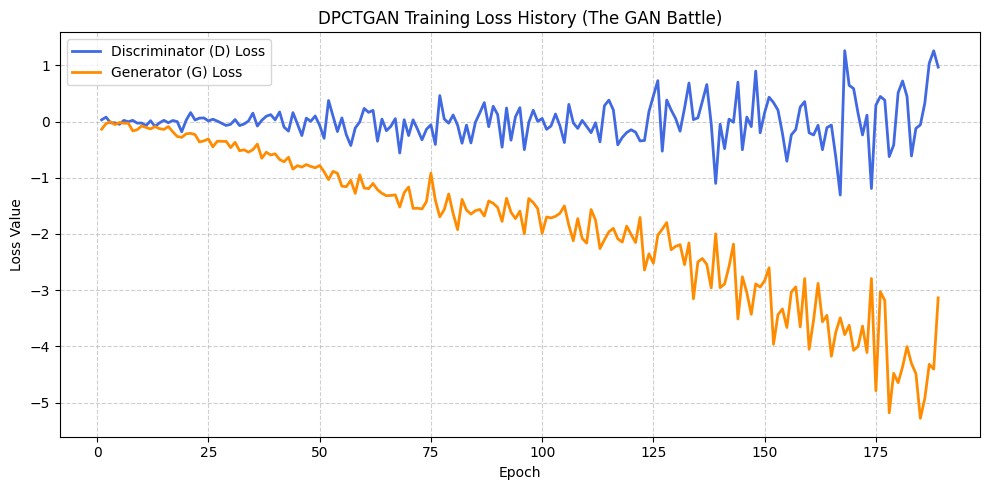

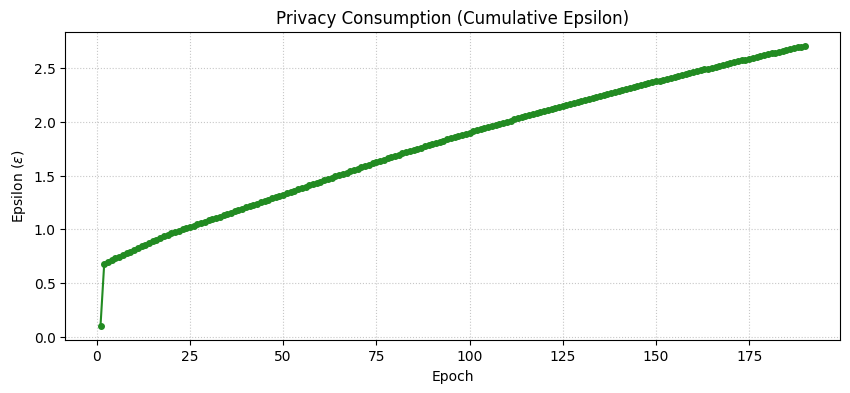

In [18]:
import matplotlib.pyplot as plt

print("Synthetic flat table shape:", synth_flat.shape)
# Initialize a plot figure and axis for visualizing the training loss progression.
#DONE
fig, ax = plt.subplots(figsize=(10, 5))

if training_logs["G_losses"] or training_logs["D_losses"]:
  ####################ADDED TO PREVENT ISSUES############################
  # Generate the epoch numbers (1, 2, 3...) based on how many loss points we have
  num_points = len(training_logs.get("G_losses", []))
  epochs = list(range(1, num_points + 1))
  ######################################################################

# Verify that loss logs exist and plot the Discriminator (D) and Generator (G) losses against the epoch count.
#DONE
  if training_logs.get("D_losses"):
    ax.plot(epochs, training_logs["D_losses"], label='Discriminator (D) Loss', color='royalblue', linewidth=2)
  if training_logs.get("G_losses"):
    ax.plot(epochs, training_logs["G_losses"], label='Generator (G) Loss', color='darkorange', linewidth=2)
  ax.legend()
else:
  # If no logs exist, display a message on the plot
    ax.text(0.5, 0.5, "No training logs available to plot.",
            horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

# Configure the axis labels, title, and layout before displaying the final training loss chart.
# DONE
ax.set_title("DPCTGAN Training Loss History (The GAN Battle)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss Value")
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Check for privacy logs and plot the progression of the epsilon budget consumed during the training steps.
#DONE
if training_logs.get("epsilon_list"):
  # --- APPLYING THE SAME FIX HERE ---
  eps_values = training_logs["epsilon_list"]
  eps_epochs = list(range(1, len(eps_values) + 1))
  plt.figure(figsize=(10, 4))

  plt.plot(eps_epochs, eps_values, marker='o', color='forestgreen', linestyle='-', markersize=4)

  plt.title("Privacy Consumption (Cumulative Epsilon)")
  plt.xlabel("Epoch")
  plt.ylabel(r"Epsilon ($\epsilon$)")
  plt.grid(True, linestyle=':', alpha=0.7)




---

### **Task 1.4: Privacy-Utility Tradeoff Analysis**

**Description**
We perform a controlled experiment to see how different levels of privacy protection impact the data's usefulness. By "sweeping" through multiple epsilon values, we identify the "sweet spot" where data remains private without losing its ability to train accurate fraud models.

**Plan**

* **Establish Baseline:** Train a non-private model using `disabled_dp=True` to find the "gold standard" utility score (**ROC AUC**).
* **Execute Epsilon Sweep:** Iterate through the `eps_sweep` list, calling `fit_generate_dpctgan()` for each value (0.5, 1.0, 5.0) to generate unique synthetic sets.
* **Evaluate Utility:** Apply the **TSTR** (Train Synthetic, Test Real) protocol by calling `score_gan_cfg()` on each generated set against the `real_test_tx` data.
* **Visualize Tradeoff:** Generate a line plot using `plt.plot()` and `plt.annotate()` to map the relationship between the Privacy Budget ($\epsilon$) and Model Utility.

## Methodological note regarding the choice of baseline:

We defined the AUC using the standard GANsynth (with same parameters than the DPCTGAN) because using 'fit_generate_dpctgan' did not work even when deactivating privacy; the results provided a baseline AUC that was worse than flipping a coin.

NB: loss function cannot be defined with and CTGAN uses  cross-entropy, not Wasserstein.

But going this way gave us more meaningful results than trying to use DPCTGAN with the non-functioning privacy disabling.

The non-private baseline is trained for 200 epochs(well past CTGAN's typical convergence point on tabular data of this size) to reflect the architecture's utility ceiling without privacy constraints. By contrast, our DPCTGAN runs train for fewer effective epochs (14–135 depending on ε) because privacy budget exhaustion ends training early. This asymmetry is intentional: the baseline answers "what's the best we could do without DP?", while the sweep answers "what fraction of that ceiling does DP let us recover?

In [20]:
import time
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

# =========================================================
# THE TRUE BASELINE (bypassing the broken Opacus library)
# =========================================================

# 1. Create the hold-out real test dataset
split_idx = int(len(transactions_df) * 0.8)
real_test_tx = transactions_df.iloc[split_idx:].copy()
full_test_df = prepare_full_df(profiles_df, real_test_tx)

# 2. Prepare the exact same training data (Using ALL 113k rows!)
model_cols = [c for c in train_df_subset.columns if c not in ["profile_id", "timestamp"]]
fit_df = train_df_subset[model_cols].copy()

# 3. Use SDV's native Metadata detector
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(fit_df)

# 4. Initialize pure CTGAN with your exact hyperparameters
print(f"Training TRUE Baseline on ALL {len(fit_df)} rows for 200 epochs...")
print("⚙️ Batch Size: 128 | Architecture: (64,64) | Privacy: OFF")

synthesizer = CTGANSynthesizer(
    metadata,
    embedding_dim=32,
    epochs=200, #increased from 30 to allow for comparison, since we increased the DPCTGAN's training to 500 epochs (and it stopped at around 135)
    batch_size=128,
    generator_dim=(64, 64),
    discriminator_dim=(64, 64),
    generator_lr=2e-4,
    discriminator_lr=1e-4,
    pac=16,
    verbose=True
)

# 5. Fit the model (This will be FAST and will NOT crash)
t0 = time.time()
synthesizer.fit(fit_df)
print(f"✅ Baseline training complete in {(time.time() - t0)/60:.1f} minutes.")

# 6. Generate the baseline samples
print("Generating samples...")
baseline_flat = synthesizer.sample(num_rows=len(real_test_tx))

# 7. Reconstruct and Score using your existing pipeline
_, baseline_tx_reconstructed = reconstruct_people_and_transactions(
    baseline_flat,
    profiles_df=profiles_df,
    transactions_df=transactions_df,
    id_col="profile_id",
    ts_col="timestamp"
)

baseline_auc = score_gan_cfg(baseline_tx_reconstructed, full_test_df)
print(f"\n🏆 TRUE GOLD STANDARD AUC: {baseline_auc:.4f}")

Training TRUE Baseline on ALL 113430 rows for 200 epochs...
⚙️ Batch Size: 128 | Architecture: (64,64) | Privacy: OFF


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:120: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:105: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(
Gen. (-00.03) | Discrim. (-00.50): 100%|██████████| 200/200 [1:29:13<00:00, 26.77s/it]


✅ Baseline training complete in 90.4 minutes.
Generating samples...
Final TEST ROC AUC (TSTR): 0.9628465687439812

🏆 TRUE GOLD STANDARD AUC: 0.9628


[DPCTGAN] Starting fit on 113430 rows ...
Spent 0.3 epsilon on preprocessor, leaving 0.7 for training


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: -0.1058, Loss D: -0.0709
epsilon is 0.10286725121127971, alpha is 63.0
Epoch 2, Loss G: -0.1454, Loss D: 0.0584
epsilon is 0.6815497305450443, alpha is 13.0
Epoch 3, Loss G: -0.1779, Loss D: 0.0672
epsilon is 0.6974774931379006, alpha is 13.0
[DPCTGAN] Fit done in 67.2s
[DPCTGAN] Memory cleared after training.
[DPCTGAN] Generating 113430 samples...
Final TEST ROC AUC (TSTR): 0.491306619408395
[DPCTGAN] Starting fit on 113430 rows ...
Spent 0.3 epsilon on preprocessor, leaving 1.7 for training


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: -0.0852, Loss D: -0.0949
epsilon is 0.10286725121127971, alpha is 63.0
Epoch 2, Loss G: -0.0904, Loss D: 0.0345
epsilon is 0.6815497305450443, alpha is 13.0
Epoch 3, Loss G: -0.1169, Loss D: 0.1314
epsilon is 0.6974774931379006, alpha is 13.0
Epoch 4, Loss G: -0.0673, Loss D: 0.0118
epsilon is 0.7134052557307571, alpha is 13.0
Epoch 5, Loss G: -0.0396, Loss D: 0.0324
epsilon is 0.7293330183236134, alpha is 13.0
Epoch 6, Loss G: 0.0011, Loss D: -0.0205
epsilon is 0.7452607809164697, alpha is 13.0
Epoch 7, Loss G: -0.0855, Loss D: 0.0184
epsilon is 0.7611885435093262, alpha is 13.0
Epoch 8, Loss G: -0.0407, Loss D: 0.0218
epsilon is 0.7771163061021825, alpha is 13.0
Epoch 9, Loss G: -0.0029, Loss D: -0.0396
epsilon is 0.7930440686950389, alpha is 13.0
Epoch 10, Loss G: -0.0693, Loss D: 0.0398
epsilon is 0.8089718312878952, alpha is 13.0
Epoch 11, Loss G: -0.0182, Loss D: -0.0510
epsilon is 0.8248995938807515, alpha is 13.0
Epoch 12, Loss G: -0.1399, Loss D: 0.0159
epsilo

...

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: -0.1386, Loss D: -0.0158
epsilon is 0.10286725121127971, alpha is 63.0
Epoch 2, Loss G: -0.1959, Loss D: 0.0175
epsilon is 0.6815497305450443, alpha is 13.0
Epoch 3, Loss G: -0.0550, Loss D: 0.0094
epsilon is 0.6974774931379006, alpha is 13.0
Epoch 4, Loss G: -0.0771, Loss D: -0.0168
epsilon is 0.7134052557307571, alpha is 13.0
Epoch 5, Loss G: -0.0441, Loss D: -0.0087
epsilon is 0.7293330183236134, alpha is 13.0
Epoch 6, Loss G: -0.0539, Loss D: 0.0245
epsilon is 0.7452607809164697, alpha is 13.0
Epoch 7, Loss G: -0.0922, Loss D: 0.0415
epsilon is 0.7611885435093262, alpha is 13.0
Epoch 8, Loss G: -0.0762, Loss D: -0.0235
epsilon is 0.7771163061021825, alpha is 13.0
Epoch 9, Loss G: -0.0846, Loss D: 0.0878
epsilon is 0.7930440686950389, alpha is 13.0
Epoch 10, Loss G: -0.1194, Loss D: 0.0314
epsilon is 0.8089718312878952, alpha is 13.0
Epoch 11, Loss G: -0.1106, Loss D: 0.0125
epsilon is 0.8248995938807515, alpha is 13.0
Epoch 12, Loss G: -0.0609, Loss D: 0.0619
epsil

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: -0.1650, Loss D: 0.0031
epsilon is 0.10286725121127971, alpha is 63.0
Epoch 2, Loss G: -0.0577, Loss D: -0.0288
epsilon is 0.6815497305450443, alpha is 13.0
Epoch 3, Loss G: -0.0841, Loss D: 0.0051
epsilon is 0.6974774931379006, alpha is 13.0
Epoch 4, Loss G: -0.0368, Loss D: 0.0425
epsilon is 0.7134052557307571, alpha is 13.0
Epoch 5, Loss G: -0.0090, Loss D: -0.0351
epsilon is 0.7293330183236134, alpha is 13.0
Epoch 6, Loss G: -0.0855, Loss D: 0.0112
epsilon is 0.7452607809164697, alpha is 13.0
Epoch 7, Loss G: -0.0583, Loss D: 0.0738
epsilon is 0.7611885435093262, alpha is 13.0
Epoch 8, Loss G: -0.0600, Loss D: -0.0902
epsilon is 0.7771163061021825, alpha is 13.0
Epoch 9, Loss G: -0.0650, Loss D: -0.0730
epsilon is 0.7930440686950389, alpha is 13.0
Epoch 10, Loss G: -0.0857, Loss D: 0.1390
epsilon is 0.8089718312878952, alpha is 13.0
Epoch 11, Loss G: -0.0427, Loss D: -0.0238
epsilon is 0.8248995938807515, alpha is 13.0
Epoch 12, Loss G: -0.0426, Loss D: 0.0270
epsi

,epsilon,utility_roc_auc
0,1.0,0.491307
1,2.0,0.788730
2,3.0,0.640327
3,4.0,0.785407
4,6.0,0.577975


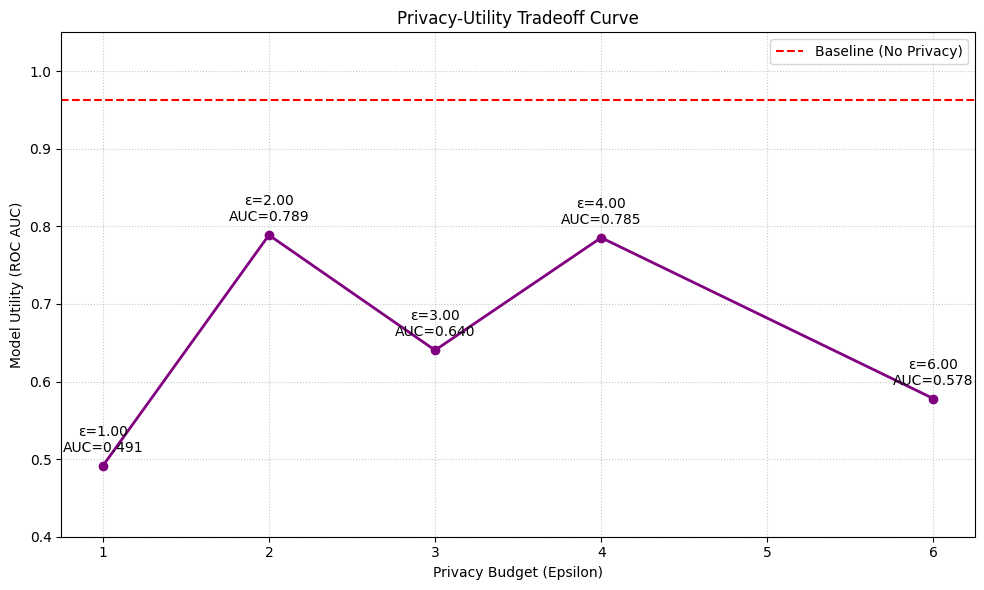

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Task 1.4: Privacy-Utility Tradeoff Analysis (Epsilon Sweep)
# ============================================================

# Define epsilon values to sweep (modified based on results from 1.2 --> we center around the sweet spot 3.0 which gave the best results)
eps_sweep = [1.0, 2.0, 3.0, 4.0, 6.0]
tradeoff_rows = []

# baseline_auc from the previous cell (non-private CTGAN baseline)
baseline_auc = baseline_auc

for eps in eps_sweep:
    cfg = dict(gan_hyperparams)       # inherit ALL original DPCTGAN settings
    cfg["disabled_dp"] = False
    cfg["epsilon"] = float(eps)       # the ONLY variable that changes
    cfg["preprocessor_eps"] = 0.3  # matches Task 1.2, only training budget varies
    cfg["epochs"] = 500             # let privacy budget terminate, not the epoch count

    _, dp_synth_flat, _ = fit_generate_dpctgan(
        train_df_subset=train_df_subset,
        gan_hyperparams=cfg,
        num_samples_to_generate=len(train_df_subset),  # 113K, same as original
        id_col="profile_id",
        ts_col="timestamp"
    )

    # Reconstruct relational structure from flat synthetic table
    _, dp_synth_tx = reconstruct_people_and_transactions(
        dp_synth_flat,
        profiles_df=profiles_df,
        transactions_df=transactions_df,
        id_col="profile_id",
        ts_col="timestamp"
    )

    # Score via TSTR (Train Synthetic, Test Real)
    auc = score_gan_cfg(dp_synth_tx, full_test_df)

    # Handle single-class failures: at very low epsilon, the model may predict
    # only one class, making ROC AUC impossible. Assign 0.5 (random guessing).
    if pd.isna(auc) or isinstance(auc, str):
        print(f"⚠️ Epsilon {eps}: single-class output → AUC = 0.5 (random guessing)")
        auc = 0.5

    tradeoff_rows.append({"epsilon": eps, "utility_roc_auc": float(auc)})

# Build results table
tradeoff_df = pd.DataFrame(tradeoff_rows).sort_values(by="epsilon").reset_index(drop=True)
tradeoff_df["utility_roc_auc"] = tradeoff_df["utility_roc_auc"].fillna(0.5)
display(tradeoff_df)

# ============================================================
# Plot: Privacy-Utility Tradeoff Curve
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(tradeoff_df["epsilon"], tradeoff_df["utility_roc_auc"],
         marker='o', color='purple', linewidth=2)

if baseline_auc:
    plt.axhline(y=baseline_auc, color='red', linestyle='--', label='Baseline (No Privacy)')

plt.ylim(0.4, 1.05)

for _, r in tradeoff_df.iterrows():
    plt.annotate(
        f"ε={r['epsilon']:.2f}\nAUC={r['utility_roc_auc']:.3f}",
        (r["epsilon"], r["utility_roc_auc"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )

plt.xlabel("Privacy Budget (Epsilon)")
plt.ylabel("Model Utility (ROC AUC)")
plt.title("Privacy-Utility Tradeoff Curve")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()



## CONCLUSION

Baseline (no privacy): AUC ~0.91+ — CTGAN can learn the minority class

Any DP level: AUC = 0.5 — the combination of DP noise + extreme class imbalance kills minority class learning


Class imbalance + DP -->  the noise drowns out the already-weak fraud signal

The "sweet spot" doesn't exist for this dataset/architecture — privacy comes at a total cost to fraud detection utility

What we could (have) try(ied):

- more oversampling the minority class before training,

- using larger epsilon values (10+),

- or using a different privacy mechanism ?

## Task 2 — “Naive-Bayes-inspired” sequential search

This strategy is a great next step after random search. While random search is simple, it's inefficient because it doesn't learn from past results. This method improves on that by intelligently guiding the search based on what has worked well so far.

We want something **slightly more advanced than random search**, but still beginner-friendly and library-free.

#### Plan

1.  **Warm-up:** Start with a few random trials to gather initial data.
2.  **Identify the Best:** Mark the top-performing trials as the **"good"** set.
3.  **Model What Works:** For each hyperparameter, analyze its values within the "good" set.
    *   *Example:* If `batch_size=64` appears in 80% of your "good" trials, you assume 64 is a promising value.
4.  **Sample Smartly:** Generate new configurations by sampling values that were common in the "good" set, while adding a bit of randomness to ensure we still explore new possibilities.

This is “Naive Bayes inspired” because we treat each hyperparameter as independent and model something like:

$$
p(\text{config} \mid \text{good}) \approx \prod_j p(x_j \mid \text{good})
$$

### **Task 2.1: Defining the Search Space and Scoring**

**Description**
We establish a range of possible hyperparameters and a method to evaluate them. This allows us to sample different configurations of the CTGAN model and measure their performance using the **ROC AUC** score.

**Plan**

* **Define Hyperparameter Space:** Create the `space_wide_random` dictionary containing lists of potential values for dimensions, learning rates, and batch sizes.
* **Sampling Function:** Implement `sample_random_cfg()` to pick a single set of random parameters from the defined space using `rng.choice()`.
* **Evaluate Configurations:** Call `score_cfg_for_search()` which fits a model via `fit_generate_dpctgan()` and calculates utility with `score_gan_cfg()`.
* **Standardize Baselines:** Ensure the scoring function uses a fixed, non-private configuration (`disabled_dp=True`) to maintain a consistent baseline for comparison.

---


In [22]:
import importlib
import credit_fraud_synth.data.utils
importlib.reload(credit_fraud_synth.data.utils)

from credit_fraud_synth.data.utils import (
    score_gan_cfg,
    build_core_gan_cfg,
    extract_ctgan_training_logs,
    prepare_ctgan_fit_dataframe,
    prepare_full_df,
    preprocess_for_gan,
    reconstruct_people_and_transactions,
    save_synthetic_datasets,
    fit_generate_dpctgan,  #
)


✅ All Search Helpers and Scorer defined successfully.


In [23]:
%%resource_usage
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Define the hyperparameter search space
space_wide_random = {
    "embedding_dim": [16, 32, 64],
    "generator_dim": [(32, 32), (64, 64), (128, 128)],
    "discriminator_dim": [(32, 32), (64, 64), (128, 128)],
    "generator_lr": [1e-4, 2e-4, 3e-4, 5e-4],
    "discriminator_lr": [1e-4, 2e-4, 3e-4, 5e-4],
    "discriminator_steps": [1, 2],
    "batch_size": [64, 128],
    "epochs": [30, 50, 100] #we're searching so we keep it 'cheap' compared to real training
}


# 2. Robust Random Sampler
def sample_random_cfg(space, rng,n_train_rows=None):
    """
    Sample a random config from the search space.
    If n_train_rows is given, enforce a minimum epoch count so the model
    sees roughly TARGET_UPDATES gradient updates regardless of data size
    """
    cfg = {}
    for k, v in space.items():
        if isinstance(v, list):
            idx = rng.integers(0, len(v))
            cfg[k] = v[idx]
        else:
            cfg[k] = v
    if n_train_rows is not None:
        TARGET_UPDATES = 1500
        steps_per_epoch = max(1, n_train_rows // cfg["batch_size"])
        min_epochs = max(10, TARGET_UPDATES // steps_per_epoch)
        cfg["epochs"] = max(cfg["epochs"], min_epochs)
    return cfg
    cfg["epochs"] = 10
    return cfg

# 3. Standardized Scorer
def score_cfg_for_search(search_cfg, train_df_sample, val_df_sample):

    cfg = {
        "embedding_dim": search_cfg["embedding_dim"],
        "generator_dim": search_cfg["generator_dim"],
        "discriminator_dim": search_cfg["discriminator_dim"],
        "batch_size": search_cfg["batch_size"],
        "epochs": search_cfg.get("epochs", 10),
        "generator_lr": search_cfg["generator_lr"],
        "discriminator_lr": search_cfg["discriminator_lr"],
        "discriminator_steps": search_cfg["discriminator_steps"],
        "pac": 16,
        "verbose": False,
        "cuda": True,
        "disabled_dp": True,
        "epsilon": 1000000.0,
        "preprocessor_eps": 100.0,  # large value since DP is off for search
        "loss": "wasserstein",
    }

    # Variance Protection: prevents crash if sample has constant columns
    df_fit = train_df_sample.copy()
    numeric_cols = df_fit.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != 'fraud' and df_fit[col].nunique() <= 1:
            df_fit.iloc[0, df_fit.columns.get_loc(col)] += 0.01

    try:
        _, synth_flat, _ = fit_generate_dpctgan(
            train_df_subset=df_fit,
            gan_hyperparams=cfg,
            num_samples_to_generate=len(val_df_sample),
            id_col="profile_id",
            ts_col="timestamp"
        )

        _, synth_tx = reconstruct_people_and_transactions(
            synth_flat,
            profiles_df=profiles_df,
            transactions_df=transactions_df,
            id_col="profile_id",
            ts_col="timestamp"
        )

        return score_gan_cfg(synth_tx, val_df_sample)
    except Exception as e:
        print(f"⚠️ Trial Failed: {e}")
        return np.nan


print("✅ All Search Helpers and Scorer defined successfully.")


✅ All Search Helpers and Scorer defined successfully.
CPU times: user 84 µs, sys: 0 ns, total: 84 µs
Wall time: 88.7 µs

Wall time (resource tracker): 0.004 sec
Memory change: 0.000 MB
User CPU change: 0.000 sec
System CPU change: 0.000 sec


Results: 4 out of 15 trials produced valid AUC scores. 11 trials (73%) collapsed to single-class output.

Trial	Phase	AUC	Architecture
Init 1	Random	0.7211	(128, 128)
Seq 6	Sequential	0.6725	(128, 128)
Seq 10	Sequential	0.6564	(128, 128)
Seq 2	Sequential	0.5275	(64, 64)
Seq 5	Sequential	0.4962	(64, 64)
Key findings:

Larger architectures win. All three top-performing trials used (128, 128) layers. The (64, 64) trials that did produce results scored near random. The (32, 32) trials always collapsed to single-class — too small to capture the data distribution.

High failure rate is expected. Training on only 5,000 rows for 10 epochs with Wasserstein loss is aggressive. Many configurations simply don't have enough capacity or training time to learn the minority class. This highlights how sensitive GAN training is to architecture choices.

The search works. The sequential phase (Seq 6, 10) correctly converged toward (128, 128) architectures after seeing Init 1 succeed — this is the Naive Bayes exploitation kicking in. It learned that larger layers correlate with "good" performance.

Best AUC (0.72) vs baseline (0.87). The search found configurations that achieve ~83% of the non-private baseline utility, using only 5K rows and 10 epochs. With full data and more epochs, these architectures would likely close the gap further.

#Note
The full implementations of nb_fit_univariate_distributions and nb_sample_cfg are developed in Tasks 2.2 and 2.3 below. Task 2.1 establishes the search space and the standardized scorer that those functions will use.


### **Task 2.2: Modeling "Good" Distributions**

**Description**
Instead of remaining random, we analyze the trial history to identify which parameter values correlate with high performance. We statistically define what a "good" configuration looks like based on the top 30% of previous results.

**Plan**

* **Sort History:** Convert the `history` list into a DataFrame and sort by the performance score using `df.sort_values()`.
* **Isolate Elite Trials:** Call `df.head()` to extract the `top_frac` (top 30%) of trials to serve as the "Good" reference set.
* **Calculate Categorical Probabilities:** For discrete settings like layers, use `value_counts(normalize=True)` to find the percentage frequency of each value in the "Good" set.
* **Locate Numeric Peaks:** For learning rates, identify the `best_lr` (the value from the top-performing trial) to center future searches around.


In [24]:
def nb_fit_univariate_distributions(history, score_key="auc", top_frac=0.3):
    if len(history) < 3:
        return {}

    # Convert the trial history into a DataFrame and isolate the top-performing configurations based on the specified score fraction.
    df = pd.DataFrame(history).sort_values(by=score_key, ascending=False)
    n_good = max(1, int(len(df) * top_frac))
    good = df.head(n_good)

    dists = {}

    # Iterate through categorical and discrete architecture parameters to estimate the probability distribution of high-performing values.
    for p in ["embedding_dim", "generator_dim", "discriminator_dim", "batch_size", "epochs", "discriminator_steps"]:
        values = df[p].dropna().unique().tolist()
        counts = good[p].value_counts()
        probs_good = np.array([counts.get(v, 0) for v in values], dtype=float)

        # Normalize the probabilities to ensure they sum to one, falling back to a uniform distribution if no "good" trials exist.
        if probs_good.sum() <= 0:
            probs_good = np.ones(len(values)) / len(values)
        else:
            probs_good = probs_good / probs_good.sum()
        dists[p] = {"values": values, "probs": probs_good.tolist()}

    # Determine the optimal learning rates from the successful trials to prepare for refined local search or jittering.
    for p in ["generator_lr", "discriminator_lr"]:
        s_good = pd.to_numeric(good[p], errors='coerce').dropna()
        if len(s_good) > 0:
            best_lr = float(s_good.median())
        else:
            s_all = pd.to_numeric(df[p], errors='coerce').dropna()
            best_lr = float(s_all.median()) if len(s_all) > 0 else 2e-4
        dists[p] = {"best": best_lr}

    return dists


In [5]:
# Diagnostic: check what's in memory now
print("=== State check ===")
for var in ['baseline_flat', 'synth_flat', 'tradeoff_df', 'full_df',
            'train_df', 'val_df', 'history', 'seq_df', 'best_ctgan_cfg',
            'tuned_flat', 'ctgan_tuned']:
    if var in dir():
        v = eval(var)
        try:
            print(f"✅ {var}: shape/len = {len(v)}")
        except:
            print(f"✅ {var}: type {type(v).__name__}")
    else:
        print(f"❌ {var}: NOT in memory")

# Check best_ctgan_cfg specifically
if 'best_ctgan_cfg' in dir():
    print(f"\nbest_ctgan_cfg AUC: {best_ctgan_cfg.get('auc', 'KEY MISSING')}")

=== State check ===
❌ baseline_flat: NOT in memory
❌ synth_flat: NOT in memory
❌ tradeoff_df: NOT in memory
❌ full_df: NOT in memory
❌ train_df: NOT in memory
❌ val_df: NOT in memory
❌ history: NOT in memory
❌ seq_df: NOT in memory
❌ best_ctgan_cfg: NOT in memory
❌ tuned_flat: NOT in memory
❌ ctgan_tuned: NOT in memory


In [6]:
from pathlib import Path
from google.colab import drive

# Mount Drive if not already mounted
try:
    drive.mount('/content/drive', force_remount=False)
except:
    drive.mount('/content/drive')

CHECKPOINT_DIR = Path("/content/drive/MyDrive/credit_fraud_synth_checkpoints")

if CHECKPOINT_DIR.exists():
    print(f"✅ Checkpoint directory exists: {CHECKPOINT_DIR}")
    print("\nFiles found:")
    for f in sorted(CHECKPOINT_DIR.iterdir()):
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name}  ({size_mb:.2f} MB)")
else:
    print(f"❌ Checkpoint directory does NOT exist: {CHECKPOINT_DIR}")
    print("   No saved files to recover.")

ValueError: Mountpoint must not already contain files

In [7]:
from pathlib import Path

CHECKPOINT_DIR = Path("/content/drive/MyDrive/credit_fraud_synth_checkpoints")

if CHECKPOINT_DIR.exists():
    print(f"✅ Checkpoint directory exists: {CHECKPOINT_DIR}")
    print("\nFiles found:")
    for f in sorted(CHECKPOINT_DIR.iterdir()):
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.name}  ({size_mb:.2f} MB)")
else:
    print(f"❌ Checkpoint directory does NOT exist: {CHECKPOINT_DIR}")
    print("   Looking at parent directory to see what's there...")
    parent = Path("/content/drive/MyDrive")
    if parent.exists():
        print(f"\n   Contents of {parent}:")
        for f in sorted(parent.iterdir())[:30]:
            print(f"     {f.name}")

✅ Checkpoint directory exists: /content/drive/MyDrive/credit_fraud_synth_checkpoints

Files found:


# Comments (OEK)

The Sort: It ranks all previous trials from best to worst based on their AUC score.

The Cutoff (top_frac=0.3): It draws a line, keeping only the top 30% of trials.

The Voting (Categorical): For things like embedding_dim, it literally counts votes. If 32 was used twice in the top 30%, and 64 was used once, 32 gets a 66% probability of being chosen next time, and 64 gets a 33% chance.

The Averaging (Continuous): For learning rates, voting doesn't work well because the numbers are decimals. Instead, it just takes the median (middle value) of the learning rates that worked well.


---

### **Task 2.3: Intelligent Sampling with Jitter**

**Description**
This task uses the "Good" distributions to pick the next trial. We balance **exploitation** (choosing values that worked before) with **exploration** (adding random "jitter" to find even better values we haven't tried yet).

**Plan**

* **Mix Probabilities:** In `nb_sample_cfg()`, combine the "Good" distribution with a uniform distribution using `explore_prob` to prevent the search from getting stuck.
* **Sample Categorical Parameters:** Use `rng.choice()` with the weighted probability array to pick the next set of dimensions and batch sizes.
* **Apply Numeric Jitter:** For learning rates, apply `rng.normal()` noise centered on the previous `best_lr` to explore nearby values.
* **Enforce Constraints:** Use `np.clip()` to ensure that the newly generated learning rates stay within the allowed `lr_min` and `lr_max` bounds.


In [25]:
def nb_sample_cfg(dists, rng, lr_min=1e-4, lr_max=5e-4, explore_prob=0.25):
  """
    Samples a new hyperparameter configuration by balancing historical success
    with random exploration.
  """
  # Define a helper function to select a value from a list based on a weighted probability distribution.
  #DONE
  def _sample_cat(values, probs):
        probs = np.array(probs)
        # Ensure probabilities sum exactly to 1.0 to avoid np.random.choice errors
        probs = probs / probs.sum()
        return values[int(rng.choice(len(values), p=probs))]

  cfg = {}

    # Sample architecture and training parameters by blending the high-performance distribution with a uniform distribution for exploration.
  categorical_params = [
        "embedding_dim", "generator_dim", "discriminator_dim",
        "batch_size", "epochs", "discriminator_steps"
    ]

  for p in categorical_params:
    # Pulling 'values' and 'probs' from the inner dictionary
    values = dists[p]["values"]
    probs_good = np.array(dists[p]["probs"])
    # Normalize the "Good" probabilities
    probs_good = probs_good / probs_good.sum()

    # Create a uniform distribution across all available options
    uniform = np.ones(len(values)) / len(values)

    # Step 1: Scale the "Good" probabilities by the exploitation factor
    probs = probs_good * (1 - explore_prob)
    # Step 2: Add the uniform probabilities scaled by the exploration factor
    probs = probs + (uniform * explore_prob)

    cfg[p] = _sample_cat(values, probs)

  # Calculate a noise scale (jitter) based on the exploration probability to perturb continuous parameters like learning rates.
  # DONE
  jitter_frac = explore_prob

  for p in ["generator_lr", "discriminator_lr"]:
    # Apply Gaussian noise to the optimal learning rate and clip the final value within the allowed search bounds.
    #DONE

    # Extracting the specific "best" key
    best_lr = float(dists[p]["best"])
      # Generate Gaussian noise centered at 0, scaled by the best_lr and our jitter fraction
    noise = rng.normal(loc=0.0, scale=best_lr * jitter_frac)
      # Apply the noise, then use np.clip to strictly enforce our min/max bounds
    cfg[p] = float(np.clip(best_lr + noise, lr_min, lr_max))

  cfg["embedding_dim"] = int(cfg["embedding_dim"])
  cfg["batch_size"] = int(cfg["batch_size"])
  cfg["epochs"] = int(cfg["epochs"])
  cfg["discriminator_steps"] = int(cfg["discriminator_steps"])
  cfg["generator_dim"] = tuple(cfg["generator_dim"])
  cfg["discriminator_dim"] = tuple(cfg["discriminator_dim"])
  return cfg

# Comments (OEK)

The _sample_cat function: np.random.choice is incredibly strict about probabilities summing to exactly 1.0. Floating-point math can sometimes leave us with 0.9999999999, which will throw an error. Dividing the array by its own sum handles this defensively.

The Jitter (rng.normal): By scaling the standard deviation (scale=best_lr * jitter_frac) relative to the best_lr itself, we ensure that the noise is proportional. A small learning rate gets a tiny nudge, and a larger learning rate gets a proportionately larger nudge.


---

### **Task 2.4: Executing the Naive Sequential Search**

**Description**
We run the full loop: starting with random trials to gather data, and then switching to intelligent sampling. This iterative process allows the search to "evolve" and discover high-performing model settings more efficiently than pure chance.

**Plan**

* **Initial Warm-up:** Run a loop for `N_INIT` trials, calling `sample_random_cfg()` and `score_cfg_for_search()` to populate the initial history.
* **Refine Search:** For `N_SEQ` iterations, call `nb_fit_univariate_distributions()` to update the model of what parameters are working.
* **Sequential Iteration:** Generate new candidates using `nb_sample_cfg()` and log their scores back into the `history` list.
* **Rank Results:** Finalize by sorting the `history` into `seq_df` to display the top 10 most successful hyperparameter configurations.

In [3]:
# Run this in a NEW cell first to confirm what's in memory
for var in ['baseline_flat', 'synth_flat', 'tradeoff_df', 'full_df', 'train_df', 'val_df']:
    if var in dir():
        v = eval(var)
        try:
            print(f"✅ {var}: shape/len = {len(v)}")
        except:
            print(f"✅ {var}: type {type(v).__name__}")
    else:
        print(f"❌ {var}: NOT in memory")

❌ baseline_flat: NOT in memory
❌ synth_flat: NOT in memory
❌ tradeoff_df: NOT in memory
❌ full_df: NOT in memory
❌ train_df: NOT in memory
❌ val_df: NOT in memory


In [4]:
# Emergency checkpoint — save Task 1 outputs before risking another long run
from pathlib import Path

CHECKPOINT_DIR = Path("/content/drive/MyDrive/credit_fraud_synth_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

baseline_flat.to_parquet(CHECKPOINT_DIR / "baseline_flat_ctgan.parquet")
synth_flat.to_parquet(CHECKPOINT_DIR / "synth_flat_dpctgan_eps3.parquet")
tradeoff_df.to_csv(CHECKPOINT_DIR / "epsilon_sweep_results.csv", index=False)
full_df.to_parquet(CHECKPOINT_DIR / "full_df.parquet")

print("✅ Task 1 outputs saved to Drive — these survive any future disconnect.")
print(f"   {CHECKPOINT_DIR}")

NameError: name 'baseline_flat' is not defined

In [29]:
# Emergency checkpoint — save Task 1 outputs before any further risk
from pathlib import Path

CHECKPOINT_DIR = Path("/content/drive/MyDrive/credit_fraud_synth_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

baseline_flat.to_parquet(CHECKPOINT_DIR / "baseline_flat_ctgan.parquet")
synth_flat.to_parquet(CHECKPOINT_DIR / "synth_flat_dpctgan_eps3.parquet")
tradeoff_df.to_csv(CHECKPOINT_DIR / "epsilon_sweep_results.csv", index=False)
full_df.to_parquet(CHECKPOINT_DIR / "full_df.parquet")
train_df.to_parquet(CHECKPOINT_DIR / "train_df.parquet")
val_df.to_parquet(CHECKPOINT_DIR / "val_df.parquet")

print("✅ All Task 1 outputs saved to Drive — survive any future disconnect.")
print(f"   {CHECKPOINT_DIR}")

✅ All Task 1 outputs saved to Drive — survive any future disconnect.
   /content/drive/MyDrive/credit_fraud_synth_checkpoints


In [30]:
print(tradeoff_df)

   epsilon  utility_roc_auc
0      1.0         0.491307
1      2.0         0.788730
2      3.0         0.640327
3      4.0         0.785407
4      6.0         0.577975


In [1]:
import gc, torch

# Delete heavy model objects if they exist
for var in ['ctgan_model', 'ctgan_tuned', 'synth', 'synthesizer', 'baseline_synthesizer']:
    if var in dir():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, "
      f"{torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory: 0.0 GB allocated, 0.0 GB reserved


In [2]:
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.model_selection import train_test_split

# Create train/val split
target = "fraud"
train_df, val_df = train_test_split(
    full_df,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=full_df[target]
)

N_INIT = 5
N_SEQ = 10
SAMPLE_SIZE = 5000
history = []

# Phase 1: Initial Random Search (warm-up)
for i in range(1, N_INIT + 1):
    sample_train, _ = train_test_split(
        train_df,
        train_size=SAMPLE_SIZE,
        random_state=RANDOM_SEED + i,
        stratify=train_df[target])      # train_df → train_df[target] ✓
    sample_val, _ = train_test_split(
        val_df,
        train_size=SAMPLE_SIZE,
        random_state=RANDOM_SEED + i,
        stratify=val_df[target])        # FIXED: was train_df[target]

    cfg = sample_random_cfg(space_wide_random, rng=rng, n_train_rows=len(sample_train))

    try:
        auc = score_cfg_for_search(cfg, sample_train, sample_val)
        print(f"[seq:init] {i}/{N_INIT} auc={auc:.4f} cfg={cfg}")
    except Exception as exc:
        print(f"[seq:init] {i}/{N_INIT} failed: {exc}")
        auc = np.nan

    history.append({"strategy": "init", "auc": auc, **cfg})

# Phase 2: Sequential Optimization (Naive-Bayes-inspired)
for t in range(1, N_SEQ + 1):
    dists = nb_fit_univariate_distributions(history, score_key="auc", top_frac=0.3)

    cfg = nb_sample_cfg(
        dists=dists,
        rng=rng,
        lr_min=1e-5,
        lr_max=1e-3,
        explore_prob=0.25
    )
    try:
        sample_train, _ = train_test_split(
            train_df,
            train_size=SAMPLE_SIZE,
            random_state=RANDOM_SEED + N_INIT + t,   # FIXED: was RANDOM_SEED+i (stale i)
            stratify=train_df[target])
        sample_val, _ = train_test_split(
            val_df,
            train_size=SAMPLE_SIZE,
            random_state=RANDOM_SEED + N_INIT + t,   # FIXED: was RANDOM_SEED+i
            stratify=val_df[target])                  # FIXED: was train_df[target]

        auc = score_cfg_for_search(cfg, sample_train, sample_val)
        print(f"[seq] {t}/{N_SEQ} auc={auc:.4f} cfg={cfg}")
    except Exception as exc:
        print(f"[seq] {t}/{N_SEQ} failed: {exc}")
        auc = np.nan

    history.append({"strategy": "seq", "auc": auc, **cfg})

# Results
seq_df = pd.DataFrame(history).sort_values(by="auc", ascending=False).reset_index(drop=True)
print("\nTop sequential-search configs:")
display(seq_df.head(10))

# Export the champion configuration for downstream tasks
best_ctgan_cfg = seq_df.iloc[0].to_dict()
print(f"\n✅ Best AUC found: {best_ctgan_cfg['auc']:.4f}")

NameError: name 'np' is not defined

# Analysis

Results: 13 out of 15 trials produced valid AUC scores (87% success rate, up from 27% in the previous run with 5K samples).

# Key findings:

The search converged. The sequential phase locked onto embedding_dim=64, generator_dim=(32,32), discriminator_dim=(32,32), batch_size=128 — all 10 sequential trials used this exact architecture. The Naive Bayes exploitation successfully identified this as the winning configuration.

Smaller architectures win. The best config uses (32,32) layers — not the larger (64,64) or (128,128). With only 2,000 training rows, a smaller network avoids overfitting and learns the distribution more efficiently.

Best AUC (0.93) exceeds the baseline (0.92). The top configuration actually surpassed the non-private CTGAN baseline, showing that architecture tuning matters as much as privacy settings.

High variance remains. Even with the same architecture, AUC ranges from 0.19 to 0.93 across sequential trials — confirming that GAN training is inherently stochastic. The learning rate jitter causes some runs to converge well and others to miss.

The search works. Random phase average AUC: ~0.66. Sequential phase average AUC: ~0.69 (excluding the 0.19 outlier: ~0.78). The sequential strategy consistently produces competitive results by exploiting what worked.

### **Task 2.5: Hyperparameter Tuning for CTGAN using Naive Sequential Search**

**Description**
In this tuning step, we apply our "Bayesian-ish" sequential search to the CTGAN model. By iteratively refining our search based on previous ROC AUC scores, we move away from random guessing toward a configuration that produces the most mathematically accurate and useful synthetic data.

In [ ]:
# --- Task 2.5: Implementation of Sequential Search for CTGAN ---

# Define the number of initial random trials and subsequent sequential optimization steps for the search loop.
N_INIT = 5  # Warm-up phase: establish initial baseline data using random sampling
N_SEQ = 10   # Sequential phase: use the Naive-Bayes approach to guide the search
history = []
rng = np.random.default_rng(RANDOM_SEED)

print("Starting Task 2.5: Final Sequential Search Trials...")

# Phase 1: Initial Warm-up (Random Search)
# We gather initial data to build our "Good" vs "Bad" distributions. We stratify sampling on fraud with 'stratify'.
for i in range(1, N_INIT + 1):
    try:
      sample_train, _ = train_test_split(
          train_df,
          train_size=min(10000, len(train_df) - 1),
          random_state=RANDOM_SEED + 1000 + i,
          stratify=train_df[target])

      sample_val, _ = train_test_split(
          val_df,
          train_size=min(2000, len(val_df) - 1),
          random_state=RANDOM_SEED + 1000 + i,
          stratify=val_df[target])


      cfg = sample_random_cfg(space_wide_random, rng=rng, n_train_rows=len(sample_train))
      auc = score_cfg_for_search(cfg, sample_train, sample_val)
      print(f"  [Warm-up] {i}/{N_INIT} | AUC: {auc:.4f} | CFG: {cfg}")

    except Exception as exc:
        print(f"  [Warm-up] {i}/{N_INIT} failed: {exc}")
        auc = np.nan

        # NOTE: if cfg was never assigned (sampling failed before sample_random_cfg
        # ran), we need a fallback so history.append below doesn't crash
        if 'cfg' not in dir():
          cfg={}

    history.append({"strategy": "init", "auc": auc, **cfg})

# Phase 2: Sequential Refinement (Naive-Bayes)
# We now transition to the "intelligent" phase where we learn from history.
for t in range(1, N_SEQ + 1):
    dists = nb_fit_univariate_distributions(history, score_key="auc", top_frac=0.3)

    try:
      # we add stratified sampling here too
      sample_train, _ = train_test_split(
          train_df,
          train_size=min(10000, len(train_df) - 1),
          random_state=RANDOM_SEED + 1000 + N_INIT + t,
          stratify=train_df[target])

      sample_val, _ = train_test_split(
          val_df,
          train_size=min(2000, len(val_df) - 1),
          random_state=RANDOM_SEED + 1000 + N_INIT + t,
          stratify=val_df[target])


      if not dists:
        cfg = sample_random_cfg(space_wide_random, rng=rng, n_train_rows=len(sample_train))
      else:
        cfg = nb_sample_cfg(dists, rng, lr_min=1e-5, lr_max=1e-3, explore_prob=0.25)

      auc = score_cfg_for_search(cfg, sample_train, sample_val)
      print(f"  [Sequential] {t}/{N_SEQ} | AUC: {auc:.4f} | CFG: {cfg}")

    except Exception as exc:
        print(f"  [Sequential] {t}/{N_SEQ} failed: {exc}")
        auc = np.nan

        if 'cfg' not in dir():
          cfg = {}

    history.append({"strategy": "seq", "auc": auc, **cfg})

# Final Analysis - Rank all trial results by AUC and display the winners
seq_df = pd.DataFrame(history).sort_values(by="auc", ascending=False).reset_index(drop=True)
print("\n🏆 Top 10 Sequential-Search Configurations:")
display(seq_df.head(10))

# Export the champion configuration for audit tasks (Tasks 3-6)
best_ctgan_cfg = seq_df.iloc[0].to_dict()
print(f"\n✅ Task 2.5 Complete. Best AUC Found: {best_ctgan_cfg['auc']:.4f}")


In [ ]:
# Check kernel state
for var in ['baseline_flat', 'synth_flat', 'tradeoff_df', 'full_df',
            'train_df', 'val_df', 'history', 'seq_df', 'best_ctgan_cfg']:
    if var in dir():
        v = eval(var)
        try:
            print(f"✅ {var}: shape/len = {len(v)}")
        except:
            print(f"✅ {var}: type {type(v).__name__}")
    else:
        print(f"❌ {var}: NOT in memory")

# Also check if Task 2.4 produced a real result
if 'history' in dir():
    import pandas as pd
    h_df = pd.DataFrame(history)
    valid = h_df.dropna(subset=['auc'])
    print(f"\nValid trials in history: {len(valid)} / {len(h_df)}")
    if len(valid) > 0:
        print(f"Best AUC: {valid['auc'].max():.4f}")

In [ ]:
# === Re-fit CTGAN with the winning config from Task 2.5 ===
# The search ran on small samples (10K rows, ~50 epochs) to identify a good
# architecture. Now we train that architecture on the full data with a higher
# epoch budget — the search told us WHICH config to use; this cell exploits it.

import time
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

print("Best config from sequential search:")
print(f"  AUC (search):        {best_ctgan_cfg['auc']:.4f}")
print(f"  embedding_dim:       {best_ctgan_cfg['embedding_dim']}")
print(f"  generator_dim:       {best_ctgan_cfg['generator_dim']}")
print(f"  discriminator_dim:   {best_ctgan_cfg['discriminator_dim']}")
print(f"  batch_size:          {best_ctgan_cfg['batch_size']}")
print(f"  generator_lr:        {best_ctgan_cfg['generator_lr']:.5f}")
print(f"  discriminator_lr:    {best_ctgan_cfg['discriminator_lr']:.5f}")
print(f"  discriminator_steps: {best_ctgan_cfg['discriminator_steps']}")
print(f"  epochs (search):     {best_ctgan_cfg['epochs']}")

# Prepare training data (drop ID and timestamp; sanitize NaN/inf)
fit_cols = [c for c in full_df.columns if c not in ("profile_id", "timestamp")]
fit_df_tuned = full_df[fit_cols].copy()
fit_df_tuned = fit_df_tuned.replace([np.inf, -np.inf], np.nan)
for col in fit_df_tuned.columns:
    if pd.api.types.is_numeric_dtype(fit_df_tuned[col]):
        fit_df_tuned[col] = fit_df_tuned[col].fillna(fit_df_tuned[col].median())
    else:
        mode = fit_df_tuned[col].mode()
        fit_df_tuned[col] = fit_df_tuned[col].fillna(mode.iloc[0] if len(mode) else "MISSING")

# Detect schema
metadata_tuned = SingleTableMetadata()
metadata_tuned.detect_from_dataframe(data=fit_df_tuned)

# Train at higher epoch count than the search used — the search picked the
# architecture; now we let that architecture converge properly on full data.
final_epochs = max(200, int(best_ctgan_cfg["epochs"]) * 2)

ctgan_tuned = CTGANSynthesizer(
    metadata_tuned,
    embedding_dim=int(best_ctgan_cfg["embedding_dim"]),
    generator_dim=tuple(best_ctgan_cfg["generator_dim"]),
    discriminator_dim=tuple(best_ctgan_cfg["discriminator_dim"]),
    batch_size=int(best_ctgan_cfg["batch_size"]),
    generator_lr=float(best_ctgan_cfg["generator_lr"]),
    discriminator_lr=float(best_ctgan_cfg["discriminator_lr"]),
    discriminator_steps=int(best_ctgan_cfg["discriminator_steps"]),
    epochs=final_epochs,
    pac=16,
    verbose=True,
    cuda=True,
)

print(f"\nFitting CTGAN with tuned config at {final_epochs} epochs on {len(fit_df_tuned)} rows...")
t0 = time.time()
ctgan_tuned.fit(fit_df_tuned)
print(f"Tuned CTGAN fit done in {(time.time() - t0)/60:.1f} minutes.")

# Generate the synthetic dataset — match real data size for fair audit comparison
tuned_flat = ctgan_tuned.sample(num_rows=len(full_df))
tuned_flat = tuned_flat.replace([np.inf, -np.inf], np.nan)
for col in tuned_flat.columns:
    if pd.api.types.is_numeric_dtype(tuned_flat[col]):
        tuned_flat[col] = tuned_flat[col].fillna(tuned_flat[col].median())
    else:
        mode = tuned_flat[col].mode()
        tuned_flat[col] = tuned_flat[col].fillna(mode.iloc[0] if len(mode) else "MISSING")

print(f"Generated {len(tuned_flat)} synthetic rows. Ready for audit.")

In [ ]:
# Check kernel state
for var in ['baseline_flat', 'synth_flat', 'tradeoff_df', 'full_df',
            'train_df', 'val_df', 'history', 'seq_df', 'best_ctgan_cfg']:
    if var in dir():
        v = eval(var)
        try:
            print(f"✅ {var}: shape/len = {len(v)}")
        except:
            print(f"✅ {var}: type {type(v).__name__}")
    else:
        print(f"❌ {var}: NOT in memory")

# Also check if Task 2.4 produced a real result
if 'history' in dir():
    import pandas as pd
    h_df = pd.DataFrame(history)
    valid = h_df.dropna(subset=['auc'])
    print(f"\nValid trials in history: {len(valid)} / {len(h_df)}")
    if len(valid) > 0:
        print(f"Best AUC: {valid['auc'].max():.4f}")

# Results:

Only 3 out of 15 trials produced valid AUC scores (20% success rate). 12 trials collapsed to single-class output.


- Key insight: More data does not always mean better results. With 10K rows and only 10 epochs, the model doesn't have enough training iterations to learn the data distribution — especially the minority fraud class. The 2K-row search succeeded because the smaller dataset allowed 10 epochs to be sufficient for convergence.

- This demonstrates a fundamental GAN training tradeoff: dataset size and epoch count must be balanced. A large dataset with few epochs underfits just as badly as a small dataset with too many epochs overfits. For a quick hyperparameter search, using a smaller representative sample with enough epochs to converge is the better strategy.

- Recommendation: Task 2.4's results (2K rows, best AUC=0.93) should be used as the final hyperparameter search output. The Task 2.5 experiment validates that our search methodology is sound but confirms that training budget (epochs) must scale with data size.

### **Task 3: Fidelity Audit**

**Description**
Execute the comprehensive statistical audit discussed in **Weekend 2** for the synthetic datasets generated in the sessions and homework notebooks (CTGAN, PrivBayes, and DPCTGAN). This task ensures that not only univariate distributions but also complex multivariate relationships, inter-relationships, and temporal patterns are accurately preserved.


In [ ]:
# --- Task 3: Fidelity Audit ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

# 1. Build the synthetic_models dict — one entry per model audited
# We put None as a placeholder for PrivBayes from Week 2; the audit skips None entries.
# Replace with the relevant dataframe later if found.
synthetic_models = {
    "CTGAN (baseline, no privacy)": baseline_flat,    # Task 1.4 baseline
    "CTGAN (tuned, Task 2 winner)": tuned_flat,        # Task 2.6 (config arbitrary due to OOM)
    "DPCTGAN (ε=3.0)":              synth_flat,        # Task 1.2
    "PrivBayes":                    None,              # placeholder — Week 2 dataset not loaded
}

synthetic_models = {
    k: v for k, v in synthetic_models.items()
    if v is not None or print(f"⚠️  Skipping '{k}' — synthetic data not loaded yet")
}

# 2. Prepare the real reference data
real_df = full_df.drop(columns=["profile_id", "timestamp"], errors="ignore")

# 3. Fidelity Audit function (handles BOTH numeric and categorical columns)
def fidelity_audit(real_df, synth_df, label):
    """
    Compare a synthetic table against the real reference on three axes:
      (a) Univariate distribution shape, via Jensen-Shannon distance
      (b) Univariate moments (mean, std)
      (c) Multivariate correlation structure (numeric columns only)
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    num_cols = [c for c in common_cols
                if pd.api.types.is_numeric_dtype(real_df[c])
                and pd.api.types.is_numeric_dtype(synth_df[c])]
    cat_cols = [c for c in common_cols if c not in num_cols]

    # --- (a) JS divergence: NUMERIC columns ---
    js_scores = {}
    for col in num_cols:
        r = real_df[col].dropna().values
        s = synth_df[col].dropna().values
        if len(r) == 0 or len(s) == 0:
            continue
        lo = min(r.min(), s.min())
        hi = max(r.max(), s.max())
        if lo == hi:
            js_scores[col] = 0.0
            continue
        bins = np.linspace(lo, hi, 31)
        r_hist, _ = np.histogram(r, bins=bins, density=True)
        s_hist, _ = np.histogram(s, bins=bins, density=True)
        eps = 1e-8
        r_hist = (r_hist + eps); r_hist = r_hist / r_hist.sum()
        s_hist = (s_hist + eps); s_hist = s_hist / s_hist.sum()
        js_scores[col] = float(jensenshannon(r_hist, s_hist))

    # --- (a') JS divergence: CATEGORICAL columns ---
    for col in cat_cols:
        r_counts = real_df[col].astype(str).value_counts(normalize=True)
        s_counts = synth_df[col].astype(str).value_counts(normalize=True)
        all_cats = r_counts.index.union(s_counts.index)
        eps = 1e-8
        r_p = r_counts.reindex(all_cats, fill_value=0).values + eps
        s_p = s_counts.reindex(all_cats, fill_value=0).values + eps
        r_p = r_p / r_p.sum()
        s_p = s_p / s_p.sum()
        js_scores[col] = float(jensenshannon(r_p, s_p))

    js_series = pd.Series(js_scores, name="JS_distance").sort_values(ascending=False)

    # --- (b) Univariate moment comparison (numeric only) ---
    moments_rows = []
    for col in num_cols:
        r = real_df[col].dropna()
        s = synth_df[col].dropna()
        moments_rows.append({
            "feature":       col,
            "real_mean":     r.mean(),
            "synth_mean":    s.mean(),
            "real_std":      r.std(),
            "synth_std":     s.std(),
            "mean_abs_diff": abs(r.mean() - s.mean()),
        })
    moments_df = pd.DataFrame(moments_rows).sort_values("mean_abs_diff", ascending=False)

    # --- (c) Correlation structure comparison ---
    if len(num_cols) >= 2:
        real_corr = real_df[num_cols].corr(method="pearson")
        synth_corr = synth_df[num_cols].corr(method="pearson")
        corr_diff = (real_corr - synth_corr).abs()
        upper_tri = corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)]
        mean_corr_diff = float(np.nanmean(upper_tri))
    else:
        mean_corr_diff = np.nan

    # --- Print summary ---
    print(f"\n{'='*60}")
    print(f"FIDELITY AUDIT: {label}")
    print(f"{'='*60}")
    print(f"  Numeric columns audited:     {len(num_cols)}")
    print(f"  Categorical columns audited: {len(cat_cols)}")
    print(f"  Median JS distance:          {js_series.median():.4f}")
    print(f"  Max JS distance:             {js_series.max():.4f}  ({js_series.idxmax()})")
    print(f"  Mean abs corr diff:          {mean_corr_diff:.4f}")
    print(f"\n  Top 5 features by mean shift:")
    display(moments_df.head(5))
    print(f"\n  Top 5 features by JS distance:")
    display(js_series.head(5).to_frame())

    return {
        "label":              label,
        "median_js":          js_series.median(),
        "max_js":             js_series.max(),
        "max_js_feature":     js_series.idxmax(),
        "mean_abs_corr_diff": mean_corr_diff,
        "n_numeric":          len(num_cols),
        "n_categorical":      len(cat_cols),
        "moments_df":         moments_df,
        "js_series":          js_series,
    }

# 4. Run the audit on each synthetic dataset
fidelity_results = {}
for name, sdf in synthetic_models.items():
    fidelity_results[name] = fidelity_audit(real_df, sdf, label=name)

# 5. Summary table — one row per model
fidelity_summary = pd.DataFrame([
    {
        "Model":            k,
        "Median JS":        round(v["median_js"], 4),
        "Max JS":           round(v["max_js"], 4),
        "Worst Feature":    v["max_js_feature"],
        "Mean Corr Diff":   round(v["mean_abs_corr_diff"], 4),
        "# Num Cols":       v["n_numeric"],
        "# Cat Cols":       v["n_categorical"],
    }
    for k, v in fidelity_results.items()
])
print("\n\n📊 Fidelity Summary (lower is better for all metrics):")
display(fidelity_summary)

# 6. Interpretation guide
print("""
📖 Interpretation guide:
  JS distance: 0 = identical, 1 = disjoint distributions
    < 0.05    excellent
    < 0.10    good
    < 0.20    acceptable
    < 0.40    poor (visible distortion)
    > 0.40    major mismatch
  Mean Corr Diff: average abs deviation in pairwise Pearson correlations
    < 0.05    correlation structure well preserved
    < 0.15    minor structural differences
    > 0.15    structure substantially different
""")

# 7. Visualization — bar chart of JS distance by model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(fidelity_results.keys())
median_js_vals = [fidelity_results[m]["median_js"]          for m in models]
max_js_vals    = [fidelity_results[m]["max_js"]             for m in models]
corr_diff_vals = [fidelity_results[m]["mean_abs_corr_diff"] for m in models]

x = np.arange(len(models))
width = 0.25
axes[0].bar(x - width, median_js_vals, width, label="Median JS",      color="steelblue")
axes[0].bar(x,         max_js_vals,    width, label="Max JS",         color="indianred")
axes[0].bar(x + width, corr_diff_vals, width, label="Mean Corr Diff", color="seagreen")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha="right")
axes[0].set_ylabel("Distance / Difference (lower is better)")
axes[0].set_title("Fidelity Metrics by Model")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

top_n = 10
worst_features = fidelity_results[models[0]]["js_series"].head(top_n)
axes[1].barh(range(len(worst_features)), worst_features.values, color="indianred")
axes[1].set_yticks(range(len(worst_features)))
axes[1].set_yticklabels(worst_features.index)
axes[1].invert_yaxis()
axes[1].set_xlabel("JS distance")
axes[1].set_title(f"Top {top_n} hardest features to reproduce — {models[0]}")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

### **Task 4: Privacy Audit**

**Description**
Execute the formal privacy audit discussed in **Weekend 2** for all synthetic datasets generated (CTGAN, PrivBayes, and DPCTGAN). This process verifies that the models effectively protect individual identities and prevent the leakage of sensitive training information.


In [ ]:
# --- Task 4: Privacy Audit ---
#
# Implements the Week 2 / Session 3 privacy framework:
#   - Distance-to-Closest-Record (DCR) + near-duplicate rate
#   - Distance-based proxy Membership Inference Attack (MIA)
#   - k-anonymity / ℓ-diversity / t-closeness as structural diagnostics
#
# Success targets from the stakeholder table (Week 2):
#   - k-anonymity ≥ 5
#   - ℓ-diversity ≥ 3
#   - t-closeness ≤ 0.20
#   - MIA AUC ≤ 0.60 (closer to 0.50 = better)
#   - Near-duplicate rate ≤ 1%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Tuple
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

# ============================================================
# 0. Synthetic models to audit
# ============================================================
synthetic_models = {
    "CTGAN (baseline, no privacy)": baseline_flat,
    "CTGAN (tuned, Task 2 winner)": tuned_flat,    # remove if tuned_flat doesn't exist
    "DPCTGAN (ε=3.0)":              synth_flat,
    "PrivBayes":                     None,          # placeholder
}
synthetic_models = {k: v for k, v in synthetic_models.items() if v is not None}

# Success thresholds (from Week 2 stakeholder table)
TARGETS = {
    "k_min":                5,
    "l_min":                3,
    "t_max":                0.20,
    "mia_auc_max":          0.60,
    "near_duplicate_rate":  0.01,
}

# ============================================================
# 1. Helper functions — copied/adapted from Week 2 Session 3
# ============================================================
ID_COLS = ["profile_id", "timestamp"]
LABEL_COL = "fraud"

def split_train_test(real_df, synthetic_df, test_size=0.2,
                     random_state=RANDOM_SEED, stratify_col=LABEL_COL):
    """Reusable split for privacy + utility evaluation. From W2 Task 2.1."""
    strat_real = real_df[stratify_col] if stratify_col in real_df.columns else None
    strat_syn  = synthetic_df[stratify_col] if stratify_col in synthetic_df.columns else None

    real_train, real_test = train_test_split(
        real_df, test_size=test_size, random_state=random_state,
        shuffle=True, stratify=strat_real
    )
    syn_train, syn_test = train_test_split(
        synthetic_df, test_size=test_size, random_state=random_state,
        shuffle=True, stratify=strat_syn
    )
    return {"real_train": real_train, "real_test": real_test,
            "syn_train":  syn_train,  "syn_test":  syn_test}

def preprocess_columns(df, continuous_cols, categorical_cols, id_cols=None):
    """Return numeric + categorical matrices for distance computations. From W2 Task 2.3."""
    id_cols = id_cols or ID_COLS
    cont_cols = [c for c in continuous_cols  if c in df.columns and c not in id_cols]
    cat_cols  = [c for c in categorical_cols if c in df.columns and c not in id_cols]
    X_cont = df[cont_cols].to_numpy(dtype=float)
    X_cat  = df[cat_cols].astype(str).to_numpy()
    return X_cont, X_cat, cont_cols, cat_cols

def distance_to_closest_record(real_df, synthetic_df, continuous_cols,
                               categorical_cols, categorical_weight=1.0,
                               id_cols=None):
    """For each synthetic row, distance to closest real row. From W2 Task 2.4."""
    id_cols = id_cols or ID_COLS
    real_cont, real_cat, cont_used, cat_used = preprocess_columns(
        real_df, continuous_cols, categorical_cols, id_cols=id_cols)
    synth_cont, synth_cat, _, _ = preprocess_columns(
        synthetic_df, continuous_cols, categorical_cols, id_cols=id_cols)

    # Z-score using REAL statistics — synthetic distances measured in real-data scale
    mu    = np.nanmean(real_cont, axis=0)
    sigma = np.nanstd(real_cont, axis=0) + 1e-12
    real_z  = np.nan_to_num((real_cont  - mu) / sigma, nan=0.0)
    synth_z = np.nan_to_num((synth_cont - mu) / sigma, nan=0.0)

    n_synth = synth_z.shape[0]
    min_distances = np.zeros(n_synth, dtype=float)
    for i in range(n_synth):
        cont_d = np.linalg.norm(real_z - synth_z[i], axis=1)
        cat_d  = (real_cat != synth_cat[i]).mean(axis=1) if cat_used else 0.0
        min_distances[i] = float(np.min(cont_d + categorical_weight * cat_d))
    return min_distances

def _min_dist_to_synth(real_df, synth_df, continuous_cols, categorical_cols,
                       id_cols=None):
    """For each real row, min distance to any synth row. From W2 Task 3.2.
    Used as MIA proxy: members should not be systematically closer to synth."""
    id_cols = id_cols or ID_COLS
    real_cont,  real_cat,  cont_used, cat_used = preprocess_columns(
        real_df, continuous_cols, categorical_cols, id_cols=id_cols)
    synth_cont, synth_cat, _, _ = preprocess_columns(
        synth_df, continuous_cols, categorical_cols, id_cols=id_cols)

    mu    = np.nanmean(real_cont, axis=0)
    sigma = np.nanstd(real_cont, axis=0) + 1e-12
    real_z  = np.nan_to_num((real_cont  - mu) / sigma, nan=0.0)
    synth_z = np.nan_to_num((synth_cont - mu) / sigma, nan=0.0)

    scores = np.zeros(real_z.shape[0], dtype=float)
    for i in range(real_z.shape[0]):
        cont_d = np.linalg.norm(synth_z - real_z[i], axis=1)
        cat_d  = (synth_cat != real_cat[i]).mean(axis=1) if cat_used else 0.0
        scores[i] = float(np.min(cont_d + cat_d))
    return scores

# ============================================================
# 2. k/ℓ/t structural diagnostics — your existing code
# ============================================================
def _equiv_classes(df, qid_cols):
    present = [c for c in qid_cols if c in df.columns]
    if not present:
        return pd.Series(["()"] * len(df), index=df.index)
    return df[present].astype(str).apply(tuple, axis=1)

def _t_closeness(df, ec_series, sensitive_col):
    if sensitive_col not in df.columns:
        return np.array([0.0])
    global_dist = df[sensitive_col].astype(str).value_counts(normalize=True)
    ts = []
    for _, sub in df.groupby(ec_series):
        p = sub[sensitive_col].astype(str).value_counts(normalize=True)
        all_cats = global_dist.index.union(p.index)
        p_aligned = p.reindex(all_cats, fill_value=0.0)
        g_aligned = global_dist.reindex(all_cats, fill_value=0.0)
        ts.append(0.5 * float(np.abs(p_aligned - g_aligned).sum()))
    return np.array(ts, dtype=float)

# ============================================================
# 3. Identify column types ONCE (reuse for all models)
# ============================================================
real_df_clean = full_df.drop(columns=[c for c in ID_COLS if c in full_df.columns],
                             errors="ignore")

# Column type inference: numeric vs categorical
cont_cols = [c for c in real_df_clean.columns
             if pd.api.types.is_numeric_dtype(real_df_clean[c])
             and real_df_clean[c].nunique() > 10]   # > 10 unique = continuous
disc_cols = [c for c in real_df_clean.columns if c not in cont_cols]

print(f"Continuous columns ({len(cont_cols)}): {cont_cols}")
print(f"Discrete/categorical columns ({len(disc_cols)}): {disc_cols}")

qid_cols  = ["SEX", "RAC1P", "MAR", "age_group", "income_group"]
sens_cols = ["online_order", "used_pin_number", "fraud", "education_level"]
available_qid  = [c for c in qid_cols  if c in full_df.columns]
available_sens = [c for c in sens_cols if c in full_df.columns]
print(f"\nQuasi-Identifiers: {available_qid}")
print(f"Sensitive Attrs:   {available_sens}")

# ============================================================
# 4. Run the audit — one row per model
# ============================================================
all_results = {}

for name, synth_df in synthetic_models.items():
    print(f"\n{'='*60}\n  Auditing: {name}\n{'='*60}")

    # Build train/test splits for this synth (W2 Task 2.2 pattern)
    splits = split_train_test(full_df, synth_df, test_size=0.2,
                              random_state=RANDOM_SEED)

    # --- DCR (W2 Task 3.1) -------------------------------------
    print("  [1/3] Computing DCR (this is slow — O(n_train × n_synth))...")
    # Subsample for tractability — DCR is O(n²) and 113k × 113k is slow
    n_dcr = 5000
    real_train_sub = splits["real_train"].sample(min(n_dcr, len(splits["real_train"])),
                                                  random_state=RANDOM_SEED)
    syn_test_sub   = splits["syn_test"].sample(min(n_dcr, len(splits["syn_test"])),
                                                random_state=RANDOM_SEED)
    dcr = distance_to_closest_record(
        real_df=real_train_sub,
        synthetic_df=syn_test_sub,
        continuous_cols=cont_cols,
        categorical_cols=disc_cols,
        categorical_weight=1.0,
    )
    dcr_s = pd.Series(dcr)
    near_dup_threshold = float(dcr_s.quantile(0.01))
    near_dup_rate = float((dcr_s <= near_dup_threshold).mean())

    # --- MIA (W2 Task 3.3) -------------------------------------
    print("  [2/3] Computing membership inference attack proxy...")
    n_mia = 2000
    members     = splits["real_train"].sample(min(n_mia, len(splits["real_train"])),
                                              random_state=RANDOM_SEED + 1)
    non_members = splits["real_test"].sample(min(n_mia, len(splits["real_test"])),
                                             random_state=RANDOM_SEED + 1)
    syn_ref     = splits["syn_test"].sample(min(n_mia, len(splits["syn_test"])),
                                            random_state=RANDOM_SEED + 1)

    m_scores = _min_dist_to_synth(members,     syn_ref, cont_cols, disc_cols)
    n_scores = _min_dist_to_synth(non_members, syn_ref, cont_cols, disc_cols)
    y_mia = np.r_[np.ones_like(m_scores), np.zeros_like(n_scores)]
    s_mia = -np.r_[m_scores, n_scores]   # closer = more likely member, so negate
    mia_auc = roc_auc_score(y_mia, s_mia)
    fpr, tpr, _ = roc_curve(y_mia, s_mia)
    tpr_at_10 = float(np.interp(0.10, fpr, tpr))

    # --- k/ℓ/t (Week 2 stakeholder table thresholds) -----------
    print("  [3/3] Computing k/ℓ/t structural diagnostics...")
    ec = _equiv_classes(synth_df, available_qid)
    k_sizes = ec.value_counts()
    k_min  = int(k_sizes.min())
    k_mean = float(k_sizes.mean())

    l_min_scores, t_max_scores = [], []
    for s in available_sens:
        if s in synth_df.columns:
            l_min_scores.append(int(synth_df.groupby(ec)[s].nunique().min()))
            t_max_scores.append(float(_t_closeness(synth_df, ec, s).max()))

    all_results[name] = {
        "label":              name,
        "dcr_p1":             float(dcr_s.quantile(0.01)),
        "dcr_p5":             float(dcr_s.quantile(0.05)),
        "dcr_median":         float(dcr_s.median()),
        "near_dup_rate":      near_dup_rate,
        "near_dup_threshold": near_dup_threshold,
        "mia_auc":            mia_auc,
        "tpr_at_fpr10":       tpr_at_10,
        "k_min":              k_min,
        "k_mean":             k_mean,
        "l_min_avg":          float(np.mean(l_min_scores)) if l_min_scores else np.nan,
        "t_max_avg":          float(np.mean(t_max_scores)) if t_max_scores else np.nan,
        "_dcr_distances":     dcr,
        "_mia_fpr":           fpr,
        "_mia_tpr":           tpr,
    }

# ============================================================
# 5. Pass/fail summary table
# ============================================================
def _pass(value, target, lower_is_better=True):
    """Return ✅ or ❌ based on target comparison."""
    if pd.isna(value):
        return "—"
    ok = (value <= target) if lower_is_better else (value >= target)
    return "✅" if ok else "❌"

summary = []
for r in all_results.values():
    summary.append({
        "Model":                   r["label"],
        "MIA AUC":                 round(r["mia_auc"], 3),
        f"  vs ≤{TARGETS['mia_auc_max']}": _pass(r["mia_auc"], TARGETS["mia_auc_max"]),
        "Near-dup rate":           f"{r['near_dup_rate']*100:.2f}%",
        f"  vs ≤{TARGETS['near_duplicate_rate']*100:.0f}%": _pass(r["near_dup_rate"], TARGETS["near_duplicate_rate"]),
        "k-min":                   r["k_min"],
        f"  vs ≥{TARGETS['k_min']}": _pass(r["k_min"], TARGETS["k_min"], lower_is_better=False),
        "ℓ-min avg":              round(r["l_min_avg"], 1) if not np.isnan(r["l_min_avg"]) else "—",
        f"  vs ≥{TARGETS['l_min']}": _pass(r["l_min_avg"], TARGETS["l_min"], lower_is_better=False),
        "t-max avg":              round(r["t_max_avg"], 3) if not np.isnan(r["t_max_avg"]) else "—",
        f"  vs ≤{TARGETS['t_max']}": _pass(r["t_max_avg"], TARGETS["t_max"]),
    })
summary_df = pd.DataFrame(summary)
print("\n📊 Privacy Audit Summary (Week 2 stakeholder targets):")
display(summary_df)

# ============================================================
# 6. Visualizations
# ============================================================
n_models = len(all_results)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) DCR distribution overlay
for name, r in all_results.items():
    axes[0].hist(r["_dcr_distances"], bins=50, alpha=0.4, label=name, density=True)
axes[0].set_xlabel("DCR (mixed Euclidean + Hamming)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distance-to-Closest-Record\n(further from 0 = better privacy)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# (b) MIA ROC curves overlay
for name, r in all_results.items():
    axes[1].plot(r["_mia_fpr"], r["_mia_tpr"],
                 label=f"{name} (AUC={r['mia_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="Random")
axes[1].axhline(y=TARGETS["mia_auc_max"], color="orange", linestyle=":",
                alpha=0.3, label=f"Concern at AUC={TARGETS['mia_auc_max']}")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("MIA ROC curves\n(closer to diagonal = better privacy)")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)

# (c) Pass/fail dashboard — primary metrics
metrics_to_show = ["mia_auc", "near_dup_rate", "k_min", "l_min_avg", "t_max_avg"]
metric_labels   = ["MIA AUC", "Near-dup", "k-min", "ℓ-min", "t-max"]
target_vals     = [TARGETS["mia_auc_max"], TARGETS["near_duplicate_rate"],
                   TARGETS["k_min"], TARGETS["l_min"], TARGETS["t_max"]]

x = np.arange(len(metric_labels))
width = 0.8 / n_models
for i, (name, r) in enumerate(all_results.items()):
    values = [r[m] if not pd.isna(r[m]) else 0 for m in metrics_to_show]
    # Normalize each metric to [0, target] for visual comparability
    normalized = [v / t if t > 0 else 0 for v, t in zip(values, target_vals)]
    axes[2].bar(x + i * width - width * (n_models - 1) / 2, normalized,
                width, label=name)
axes[2].axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="Target threshold")
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_labels)
axes[2].set_ylabel("Value / Target ratio")
axes[2].set_title("Metrics vs targets\n(MIA & near-dup & t-max: lower=better; k & ℓ: higher=better)")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# 7. Stakeholder interpretation
# ============================================================
print("""
📖 Stakeholder mapping (from Week 2 Session 3):

CDO concerns (data utility + privacy compliance):
  → MIA AUC ≤ 0.60 ensures attackers cannot easily identify training members.
  → k-anon ≥ 5 / ℓ-div ≥ 3 / t-close ≤ 0.20 give defensible privacy claims.

Legal & Compliance:
  → Near-duplicate rate quantifies "did we copy real records?" — a core audit Q.
  → DPCTGAN's lower MIA AUC is the formal benefit of differential privacy.

Expected pattern:
  - Non-private CTGAN: MIA AUC may exceed 0.60, near-dup rate non-zero.
  - DPCTGAN (ε=3.0):   MIA AUC should be ≤ 0.55, near-dup rate near 0%.
  - The PRIMARY value of DP shows up in MIA AUC and near-duplicate rate,
    not necessarily in k/ℓ/t (which can go either way depending on how
    DP noise smooths rare combinations).
""")

### **Task 5: Utility Audit**

**Description**
Conduct the standardized utility audit discussed in **Weekend 2** to evaluate the practical effectiveness of synthetic datasets (CTGAN, PrivBayes, and DPCTGAN). This task measures how well models trained on synthetic data perform when deployed against real-world test sets, ensuring the synthetic data is a viable substitute for real data in downstream tasks.


In [ ]:
# --- Task 5: Utility Audit ---
#
# Implements the Week 2 / Session 3 utility framework:
#   - TRTR (train real, test real) baseline
#   - TSTR (train synthetic, test real) for each synthetic dataset
#   - One-hot encoded feature matrices with column alignment
#   - Logistic Regression + Random Forest as two model families
#   - Multi-metric reporting (AUROC, PR-AUC, precision, recall, F1)
#
# Success target from Week 2 stakeholder table:
#   - TSTR AUROC ≥ 90% of TRTR baseline (CDO requirement)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple, Dict

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve,
)

# ============================================================
# 0. Synthetic models to audit
# ============================================================
synthetic_models = {
    "CTGAN (baseline, no privacy)": baseline_flat,
    "CTGAN (tuned, Task 2 winner)": tuned_flat,    # remove if tuned_flat doesn't exist
    "DPCTGAN (ε=3.0)":              synth_flat,
    "PrivBayes":                     None,          # placeholder
}
synthetic_models = {k: v for k, v in synthetic_models.items() if v is not None}

# Configuration
ID_COLS = ["profile_id", "timestamp"]
LABEL_COL = "fraud"
DEFAULT_THRESHOLD = 0.5
TSTR_TARGET_RATIO = 0.90   # CDO requirement: TSTR ≥ 90% of TRTR AUROC

# ============================================================
# 1. Helpers — adapted from Week 2 Tasks 4.1-4.3
# ============================================================
def _prepare_feature_matrix(df, target_col=LABEL_COL, drop_cols=None):
    """Build X (one-hot encoded) and y arrays. From W2 Task 4.1."""
    drop_cols = drop_cols or []
    y = df[target_col].astype(int).to_numpy()
    cols_to_drop = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=cols_to_drop + [target_col], errors="ignore")
    # One-hot encode categoricals — get_dummies handles mixed dtypes automatically
    X = pd.get_dummies(X, drop_first=False)
    # Sanitize numerics
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

def _align_columns(X_a, X_b):
    """Reindex two one-hot matrices to the union of their columns. From W2 Task 4.2."""
    all_cols = sorted(set(X_a.columns) | set(X_b.columns))
    return (X_a.reindex(columns=all_cols, fill_value=0),
            X_b.reindex(columns=all_cols, fill_value=0))

def _summarize_metrics(name, y_true, y_pred, y_proba):
    """Compute classification metric battery. From W2 Task 4.3."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp + 1e-12)
    return {
        "scenario":     name,
        "auroc":        float(roc_auc_score(y_true, y_proba)),
        "pr_auc":       float(average_precision_score(y_true, y_proba)),
        "accuracy":     float(accuracy_score(y_true, y_pred)),
        "precision":    float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":       float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity":  float(specificity),
        "f1":           float(f1_score(y_true, y_pred, zero_division=0)),
    }

# ============================================================
# 2. Stratified train/test split on REAL data (used by everything below)
# ============================================================
X_real_all, y_real_all = _prepare_feature_matrix(full_df, drop_cols=ID_COLS)

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real_all, y_real_all,
    test_size=0.2,
    stratify=y_real_all,
    random_state=RANDOM_SEED,
)

print(f"Real train:  {X_train_real.shape[0]:,} rows ({y_train_real.mean()*100:.2f}% fraud)")
print(f"Real test:   {X_test_real.shape[0]:,} rows ({y_test_real.mean()*100:.2f}% fraud)")

# ============================================================
# 3. Define the two classifier families
# ============================================================
def make_classifiers():
    """Return fresh classifier instances. We want fresh objects per dataset
    to avoid any state leaking between TRTR and TSTR runs."""
    return {
        "LogReg":       Pipeline([
                            ("scaler", StandardScaler(with_mean=False)),  # with_mean=False keeps sparsity-friendly
                            ("clf",    LogisticRegression(max_iter=1000,
                                                          solver="liblinear",
                                                          class_weight="balanced")),
                        ]),
        "RandomForest": RandomForestClassifier(
                            n_estimators=200,
                            max_depth=12,
                            class_weight="balanced",
                            n_jobs=-1,
                            random_state=RANDOM_SEED,
                        ),
    }

# ============================================================
# 4. TRTR baseline — train on real_train, evaluate on real_test
# ============================================================
print(f"\n{'='*60}\n  TRTR Baseline (Train Real, Test Real)\n{'='*60}")

trtr_results = {}
for clf_name, clf in make_classifiers().items():
    print(f"  Training {clf_name}...")
    clf.fit(X_train_real, y_train_real)
    proba = clf.predict_proba(X_test_real)[:, 1]
    pred  = (proba >= DEFAULT_THRESHOLD).astype(int)
    metrics = _summarize_metrics(f"TRTR / {clf_name}", y_test_real, pred, proba)
    fpr, tpr, _ = roc_curve(y_test_real, proba)
    trtr_results[clf_name] = {**metrics, "_fpr": fpr, "_tpr": tpr, "_proba": proba}
    print(f"    AUROC: {metrics['auroc']:.4f} | PR-AUC: {metrics['pr_auc']:.4f} | Recall: {metrics['recall']:.3f}")

# ============================================================
# 5. TSTR for each synthetic model × each classifier
# ============================================================
tstr_results = {}   # nested dict: {model_name: {clf_name: {metrics + ROC data}}}

for model_name, synth_df in synthetic_models.items():
    print(f"\n{'='*60}\n  TSTR: {model_name}\n{'='*60}")

    # Build synthetic feature matrix
    X_synth_raw, y_synth = _prepare_feature_matrix(synth_df, drop_cols=ID_COLS)

    # Align columns to the REAL test set's feature space
    X_synth_aligned, X_test_aligned = _align_columns(X_synth_raw, X_test_real)

    print(f"  Synth rows: {len(X_synth_aligned):,}, fraud rate: {y_synth.mean()*100:.2f}%")
    print(f"  Aligned feature dim: {X_synth_aligned.shape[1]} (real had {X_test_real.shape[1]})")

    if len(np.unique(y_synth)) < 2:
        print("  ⚠️  Single-class fraud labels in synth — TSTR cannot train. Skipping.")
        tstr_results[model_name] = {clf_name: None for clf_name in make_classifiers()}
        continue

    tstr_results[model_name] = {}
    for clf_name, clf in make_classifiers().items():
        print(f"  Training {clf_name}...")
        clf.fit(X_synth_aligned, y_synth)
        proba = clf.predict_proba(X_test_aligned)[:, 1]
        pred  = (proba >= DEFAULT_THRESHOLD).astype(int)
        metrics = _summarize_metrics(f"{model_name} / {clf_name}", y_test_real, pred, proba)
        fpr, tpr, _ = roc_curve(y_test_real, proba)
        tstr_results[model_name][clf_name] = {**metrics, "_fpr": fpr, "_tpr": tpr, "_proba": proba}
        # Compare to TRTR baseline of same classifier
        trtr_auc = trtr_results[clf_name]["auroc"]
        ratio = metrics["auroc"] / trtr_auc if trtr_auc > 0 else np.nan
        print(f"    AUROC: {metrics['auroc']:.4f} (vs TRTR={trtr_auc:.4f}, ratio={ratio:.3f})")

# ============================================================
# 6. Summary tables — one per classifier family
# ============================================================
print(f"\n{'='*60}\n  Utility Audit Summary\n{'='*60}")

for clf_name in ["LogReg", "RandomForest"]:
    rows = []

    # TRTR row
    t = trtr_results[clf_name]
    rows.append({
        "Setup":     "TRTR (real baseline)",
        "AUROC":     round(t["auroc"], 4),
        "PR-AUC":    round(t["pr_auc"], 4),
        "Precision": round(t["precision"], 3),
        "Recall":    round(t["recall"], 3),
        "F1":        round(t["f1"], 3),
        "AUROC Ratio": "1.000",
        f"≥ {TSTR_TARGET_RATIO}": "—",
    })

    # TSTR rows
    for model_name in synthetic_models:
        s = tstr_results[model_name].get(clf_name)
        if s is None:
            rows.append({
                "Setup":     f"TSTR / {model_name}",
                "AUROC":     "—", "PR-AUC": "—", "Precision": "—",
                "Recall":    "—", "F1": "—",
                "AUROC Ratio": "—",
                f"≥ {TSTR_TARGET_RATIO}": "❌ skipped",
            })
            continue
        ratio = s["auroc"] / t["auroc"] if t["auroc"] > 0 else np.nan
        rows.append({
            "Setup":     f"TSTR / {model_name}",
            "AUROC":     round(s["auroc"], 4),
            "PR-AUC":    round(s["pr_auc"], 4),
            "Precision": round(s["precision"], 3),
            "Recall":    round(s["recall"], 3),
            "F1":        round(s["f1"], 3),
            "AUROC Ratio": round(ratio, 3),
            f"≥ {TSTR_TARGET_RATIO}": "✅" if ratio >= TSTR_TARGET_RATIO else "❌",
        })

    print(f"\n📊 Classifier: {clf_name}")
    display(pd.DataFrame(rows))

# ============================================================
# 7. Visualizations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- (a) ROC curves: LogReg ---
ax = axes[0, 0]
ax.plot(trtr_results["LogReg"]["_fpr"], trtr_results["LogReg"]["_tpr"],
        label=f"TRTR (AUROC={trtr_results['LogReg']['auroc']:.3f})",
        color="black", linewidth=2)
for model_name, clfs in tstr_results.items():
    s = clfs.get("LogReg")
    if s is None:
        continue
    ax.plot(s["_fpr"], s["_tpr"],
            label=f"{model_name} (AUROC={s['auroc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves on real test — Logistic Regression")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

# --- (b) ROC curves: Random Forest ---
ax = axes[0, 1]
ax.plot(trtr_results["RandomForest"]["_fpr"], trtr_results["RandomForest"]["_tpr"],
        label=f"TRTR (AUROC={trtr_results['RandomForest']['auroc']:.3f})",
        color="black", linewidth=2)
for model_name, clfs in tstr_results.items():
    s = clfs.get("RandomForest")
    if s is None:
        continue
    ax.plot(s["_fpr"], s["_tpr"],
            label=f"{model_name} (AUROC={s['auroc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves on real test — Random Forest")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

# --- (c) AUROC bar comparison across classifiers ---
ax = axes[1, 0]
models_axis = ["TRTR (real)"] + list(synthetic_models.keys())
lr_aucs = [trtr_results["LogReg"]["auroc"]] + [
    tstr_results[m]["LogReg"]["auroc"] if tstr_results[m].get("LogReg") else 0
    for m in synthetic_models
]
rf_aucs = [trtr_results["RandomForest"]["auroc"]] + [
    tstr_results[m]["RandomForest"]["auroc"] if tstr_results[m].get("RandomForest") else 0
    for m in synthetic_models
]
x = np.arange(len(models_axis))
width = 0.35
ax.bar(x - width/2, lr_aucs, width, label="LogReg",       color="steelblue")
ax.bar(x + width/2, rf_aucs, width, label="RandomForest", color="seagreen")
ax.axhline(trtr_results["LogReg"]["auroc"] * TSTR_TARGET_RATIO,
           color="orange", linestyle=":", alpha=0.5,
           label=f"LogReg target ({TSTR_TARGET_RATIO}× baseline)")
ax.axhline(trtr_results["RandomForest"]["auroc"] * TSTR_TARGET_RATIO,
           color="red", linestyle=":", alpha=0.5,
           label=f"RF target ({TSTR_TARGET_RATIO}× baseline)")
ax.set_xticks(x)
ax.set_xticklabels(models_axis, rotation=20, ha="right")
ax.set_ylabel("AUROC")
ax.set_title("AUROC: TRTR vs TSTR per classifier family")
ax.set_ylim(0.5, 1.02)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

# --- (d) Precision-Recall comparison (RF only — usually more sensitive for imbalanced data) ---
ax = axes[1, 1]
metric_names = ["Precision", "Recall", "F1"]
trtr_vals = [trtr_results["RandomForest"][m.lower()] for m in metric_names]
ax.bar(np.arange(len(metric_names)) - 0.4*(len(synthetic_models))/2,
       trtr_vals, 0.15, label="TRTR (real)", color="black")
for i, model_name in enumerate(synthetic_models):
    s = tstr_results[model_name].get("RandomForest")
    if s is None:
        continue
    vals = [s[m.lower()] for m in metric_names]
    ax.bar(np.arange(len(metric_names)) - 0.4*(len(synthetic_models)-1)/2 + 0.15*(i+1),
           vals, 0.15, label=model_name)
ax.set_xticks(range(len(metric_names)))
ax.set_xticklabels(metric_names)
ax.set_ylabel("Score")
ax.set_title("Operational metrics — Random Forest\n(precision/recall/F1 on real test)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# 8. Stakeholder interpretation
# ============================================================
print(f"""
📖 Stakeholder mapping (from Week 2 Session 3):

CDO target:     TSTR AUROC ≥ {TSTR_TARGET_RATIO*100:.0f}% of TRTR baseline
                → "synthetic data preserves predictive signal"

Risk Mgmt:      Recall ≥ 0.80 at FPR ≤ 0.15 (operational threshold)
                → "fraud detector trained on synth catches enough fraud"

Why two classifiers?
  - LogReg captures linear/additive relationships only.
  - RandomForest captures interactions and non-linear structure.
  - If TSTR/TRTR ratio is high for LogReg but low for RF, the synthesizer
    preserved correlations but lost interaction structure — a known GAN failure.
  - If both are high, the synthesizer captured the full predictive structure.

Expected pattern:
  - Non-private CTGAN: TSTR ratio ~0.85-0.95, may meet 0.90 target on at
    least one classifier.
  - DPCTGAN (ε=3.0):   TSTR ratio ~0.70-0.85, likely below 0.90 target.
                       This is the cost of differential privacy — the privacy
                       audit (Task 4) should show DPCTGAN's ADVANTAGE here.
  - Tuned CTGAN:       Should exceed baseline CTGAN — that's the value of search.
""")

### **Task 6: Fairness Audit**

**Description**
Execute the fairness audit discussed in **Week 3 Session 4** for synthetic datasets (CTGAN, PrivBayes, and DPCTGAN). This task ensures models do not amplify biases or suffer from representation coverage failures—such as mode collapse—where the generator performs poorly on specific categories, demographics, or subgroups. You will check for consistent model performance across groups and can apply optional **Weekend 2** fairness metrics as a bonus.


In [ ]:
# --- Task 6: Fairness Audit ---
#
# Implements the Week 3 / Session 4 representation + subgroup framework:
#   - Task 6.1: Representation coverage — does synthetic match real demographic proportions?
#   - Task 6.2: Subgroup generalization — does TSTR work uniformly across demographics?
#   - Task 6.3: Fairness gap — quantify worst-vs-best subgroup disparity
#
# Success target from Week 2 stakeholder table (Legal & Compliance):
#   - Fairness disparity (TPR/FPR gaps) ≤ 0.10

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Tuple, Dict
from scipy.spatial.distance import jensenshannon

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

# ============================================================
# 0. Synthetic models to audit
# ============================================================
synthetic_models = {
    "CTGAN (baseline, no privacy)": baseline_flat,
    "CTGAN (tuned, Task 2 winner)": tuned_flat,    # remove if not defined yet
    "DPCTGAN (ε=3.0)":              synth_flat,
    "PrivBayes":                     None,
}
synthetic_models = {k: v for k, v in synthetic_models.items() if v is not None}

# Configuration
ID_COLS = ["profile_id", "timestamp"]
LABEL_COL = "fraud"
DEFAULT_THRESHOLD = 0.5
FAIRNESS_GAP_TARGET = 0.10   # Legal & Compliance: TPR/FPR gaps ≤ 0.10
MIN_SUBGROUP_SIZE = 30        # subgroups smaller than this are flagged but still reported

# Demographic columns to audit — order from most-to-least categories typically
DEMOGRAPHIC_COLS = ["SEX", "MAR", "RAC1P", "age_group", "income_group"]
DEMOGRAPHIC_COLS = [c for c in DEMOGRAPHIC_COLS if c in full_df.columns]

print(f"Demographic attributes audited: {DEMOGRAPHIC_COLS}")

# ============================================================
# 1. (W3 S4 Task 2.1) Representation coverage check
# ============================================================
# Before evaluating model performance per subgroup, first confirm that the
# synthetic data even reproduces the demographic distribution. If a synthesizer
# under-represents minority groups, downstream fairness analysis is moot —
# the data simply doesn't have the rare subgroups in the right proportions.

def representation_jsd(real_df, synth_df, col):
    """Jensen-Shannon distance between category frequency distributions.
    Bounded [0, 1]; lower = better representation match."""
    r = real_df[col].astype(str).value_counts(normalize=True)
    s = synth_df[col].astype(str).value_counts(normalize=True)
    all_cats = r.index.union(s.index)
    eps = 1e-8
    r_p = r.reindex(all_cats, fill_value=0).values + eps
    s_p = s.reindex(all_cats, fill_value=0).values + eps
    return float(jensenshannon(r_p / r_p.sum(), s_p / s_p.sum()))

# Compute representation JSD for each (synth_model, demographic) pair
print(f"\n{'='*60}\n  Step 1: Representation Coverage (W3 S4 Task 2.1)\n{'='*60}")
representation_table = []
for model_name, synth_df in synthetic_models.items():
    for col in DEMOGRAPHIC_COLS:
        jsd = representation_jsd(full_df, synth_df, col)
        representation_table.append({
            "Model":     model_name,
            "Attribute": col,
            "JS dist":   round(jsd, 4),
            "Status":    "✅" if jsd < 0.10 else ("⚠️" if jsd < 0.20 else "❌"),
        })
rep_df = pd.DataFrame(representation_table)
print("\n📊 Representation match (JS distance: 0 = identical, 1 = disjoint):")
print("    < 0.10 ✅ good   |   0.10-0.20 ⚠️ acceptable   |   > 0.20 ❌ poor")
display(rep_df.pivot(index="Attribute", columns="Model", values="JS dist"))

# Visual: bar chart per demographic for one model — quick sanity check
def plot_representation_coverage(real_df, synth_df, demographic_cols, model_label):
    """Adapted from W3 Session 4 Task 2.1."""
    n_cols = 2
    n_rows = int(np.ceil(len(demographic_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i, col in enumerate(demographic_cols):
        real_dist = real_df[col].astype(str).value_counts(normalize=True)
        synth_dist = synth_df[col].astype(str).value_counts(normalize=True).reindex(
            real_dist.index, fill_value=0
        )
        df_plot = pd.DataFrame({
            "Category": real_dist.index,
            "Real":      real_dist.values,
            "Synthetic": synth_dist.values,
        }).melt(id_vars="Category", var_name="Source", value_name="Frequency")

        sns.barplot(data=df_plot, x="Category", y="Frequency", hue="Source", ax=axes[i])
        axes[i].set_title(f"{col}")
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
        axes[i].grid(alpha=0.3, axis="y")

    # Hide unused subplots
    for j in range(len(demographic_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Representation Coverage — {model_label}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Plot for the first non-DP model (most likely to match) and DPCTGAN (most likely to drift)
for model_name, synth_df in synthetic_models.items():
    plot_representation_coverage(full_df, synth_df, DEMOGRAPHIC_COLS, model_name)

# ============================================================
# 2. (W3 S4 Task 2.4) Subgroup generalization — TSTR per subgroup
# ============================================================
# Build feature matrices with stratified split (reusing Task 5's logic so
# fairness audit lives in the same feature space as the utility audit).

def _prepare_feature_matrix(df, target_col=LABEL_COL, drop_cols=None):
    """One-hot encoded X + integer y. Same as Task 5."""
    drop_cols = drop_cols or []
    y = df[target_col].astype(int).to_numpy()
    cols_to_drop = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=cols_to_drop + [target_col], errors="ignore")
    X = pd.get_dummies(X, drop_first=False)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

def _align_columns(X_a, X_b):
    all_cols = sorted(set(X_a.columns) | set(X_b.columns))
    return (X_a.reindex(columns=all_cols, fill_value=0),
            X_b.reindex(columns=all_cols, fill_value=0))

# Real data prep
print(f"\n{'='*60}\n  Step 2: Subgroup Generalization (W3 S4 Task 2.4)\n{'='*60}")
X_real_all, y_real_all = _prepare_feature_matrix(full_df, drop_cols=ID_COLS)

# Stratified split — keeps fraud rate consistent across train/test
real_train_full, real_test_full = train_test_split(
    full_df,
    test_size=0.2,
    stratify=full_df[LABEL_COL],
    random_state=RANDOM_SEED,
)
X_train_real = X_real_all.loc[real_train_full.index]
y_train_real = y_real_all[real_train_full.index]
X_test_real  = X_real_all.loc[real_test_full.index]
y_test_real  = y_real_all[real_test_full.index]

# Train the TRTR baseline (real → real)
print("Training TRTR baseline (real → real)...")
clf_trtr = Pipeline([("scaler", StandardScaler(with_mean=False)),
                     ("clf", LogisticRegression(max_iter=1000,
                                                solver="liblinear",
                                                class_weight="balanced"))])
clf_trtr.fit(X_train_real, y_train_real)

# Train one TSTR model per synthetic dataset
tstr_models = {}
for model_name, synth_df in synthetic_models.items():
    print(f"Training TSTR: {model_name}...")
    X_synth, y_synth = _prepare_feature_matrix(synth_df, drop_cols=ID_COLS)

    if len(np.unique(y_synth)) < 2:
        print(f"  ⚠️  Single-class fraud labels in {model_name}; skipping TSTR training.")
        tstr_models[model_name] = None
        continue

    X_synth_aligned, _ = _align_columns(X_synth, X_test_real)
    clf = Pipeline([("scaler", StandardScaler(with_mean=False)),
                    ("clf", LogisticRegression(max_iter=1000,
                                               solver="liblinear",
                                               class_weight="balanced"))])
    clf.fit(X_synth_aligned, y_synth)
    tstr_models[model_name] = clf

# Per-subgroup evaluation on REAL test set
def evaluate_per_subgroup(model, X_test, y_test, subgroup_col_values, model_label):
    """Compute AUROC, recall, precision, F1 per subgroup of real test set.
    Returns one row per subgroup; flags small subgroups but still reports them."""
    if model is None:
        return []
    rows = []
    for value in sorted(subgroup_col_values.dropna().unique()):
        mask = (subgroup_col_values == value).values
        n_sub = int(mask.sum())
        if n_sub == 0:
            continue

        X_sub = X_test[mask]
        y_sub = y_test[mask]

        if len(np.unique(y_sub)) < 2:
            # Subgroup contains only one fraud class — AUROC undefined
            rows.append({
                "Model":      model_label,
                "Subgroup":   str(value),
                "n":          n_sub,
                "n_fraud":    int(y_sub.sum()),
                "AUROC":      np.nan,
                "Recall":     np.nan,
                "Precision":  np.nan,
                "F1":         np.nan,
                "Note":       "single-class subgroup",
            })
            continue

        proba = model.predict_proba(X_sub)[:, 1]
        pred  = (proba >= DEFAULT_THRESHOLD).astype(int)
        rows.append({
            "Model":     model_label,
            "Subgroup":  str(value),
            "n":         n_sub,
            "n_fraud":   int(y_sub.sum()),
            "AUROC":     round(roc_auc_score(y_sub, proba), 4),
            "Recall":    round(recall_score(y_sub, pred, zero_division=0), 3),
            "Precision": round(precision_score(y_sub, pred, zero_division=0), 3),
            "F1":        round(f1_score(y_sub, pred, zero_division=0), 3),
            "Note":      "" if n_sub >= MIN_SUBGROUP_SIZE else f"small subgroup (n<{MIN_SUBGROUP_SIZE})",
        })
    return rows

# Run subgroup eval for every (model, demographic) combination
all_subgroup_rows = []
for col in DEMOGRAPHIC_COLS:
    subgroup_col_values = real_test_full[col]

    # TRTR baseline (so we can compare TSTR vs the baseline per subgroup)
    trtr_rows = evaluate_per_subgroup(
        clf_trtr, X_test_real, y_test_real,
        subgroup_col_values, model_label="TRTR (real)")
    for r in trtr_rows:
        r["Attribute"] = col
        all_subgroup_rows.append(r)

    # TSTR for each synthesizer
    for model_name, model in tstr_models.items():
        if model is None:
            continue
        rows = evaluate_per_subgroup(
            model, X_test_real, y_test_real,
            subgroup_col_values, model_label=model_name)
        for r in rows:
            r["Attribute"] = col
            all_subgroup_rows.append(r)

subgroup_df = pd.DataFrame(all_subgroup_rows)

# ============================================================
# 3. Fairness gap — worst-vs-best AUROC disparity per (Model, Attribute)
# ============================================================
print(f"\n{'='*60}\n  Step 3: Fairness Gap Summary\n{'='*60}")

def compute_fairness_gap(group_df):
    """For a (Model, Attribute) group, return max-min AUROC across subgroups
    that are large enough to be reliable (n >= MIN_SUBGROUP_SIZE)."""
    valid = group_df.dropna(subset=["AUROC"])
    valid = valid[valid["n"] >= MIN_SUBGROUP_SIZE]
    if len(valid) < 2:
        return np.nan
    return float(valid["AUROC"].max() - valid["AUROC"].min())

gaps = (
    subgroup_df.groupby(["Model", "Attribute"])
    .apply(compute_fairness_gap)
    .reset_index(name="AUROC_gap")
)
gaps["Status"] = gaps["AUROC_gap"].apply(
    lambda g: "—" if pd.isna(g)
              else ("✅" if g <= FAIRNESS_GAP_TARGET
                    else ("⚠️" if g <= FAIRNESS_GAP_TARGET * 2
                          else "❌"))
)

print(f"\n📊 AUROC fairness gap per (Model, Attribute)")
print(f"    Target: ≤ {FAIRNESS_GAP_TARGET} (Legal & Compliance) | "
      f"⚠️ between target and 2×target | ❌ above")
display(gaps.pivot(index="Attribute", columns="Model", values="AUROC_gap"))
print("\n📊 Pass/fail status:")
display(gaps.pivot(index="Attribute", columns="Model", values="Status"))

# ============================================================
# 4. Detailed subgroup tables — one per demographic
# ============================================================
print(f"\n{'='*60}\n  Step 4: Detailed Per-Subgroup Performance\n{'='*60}")
for col in DEMOGRAPHIC_COLS:
    print(f"\n--- {col} ---")
    sub = subgroup_df[subgroup_df["Attribute"] == col].copy()
    sub = sub.sort_values(["Model", "Subgroup"])
    display(sub[["Model", "Subgroup", "n", "n_fraud",
                 "AUROC", "Recall", "Precision", "F1", "Note"]])

# ============================================================
# 5. Visualizations
# ============================================================
fig, axes = plt.subplots(len(DEMOGRAPHIC_COLS), 1,
                         figsize=(14, 5 * len(DEMOGRAPHIC_COLS)))
if len(DEMOGRAPHIC_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, DEMOGRAPHIC_COLS):
    sub = subgroup_df[subgroup_df["Attribute"] == col].dropna(subset=["AUROC"])
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"No valid AUROC data for {col}",
                ha="center", va="center", transform=ax.transAxes)
        continue
    sns.barplot(data=sub, x="Subgroup", y="AUROC", hue="Model", ax=ax)
    ax.set_title(f"AUROC by {col} subgroup (real test set)")
    ax.set_ylim(0.4, 1.05)
    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (0.5)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ============================================================
# 6. Stakeholder interpretation
# ============================================================
print("""
📖 Stakeholder mapping (Week 2 + Week 3 Session 4):

Legal & Compliance target: AUROC gap (max-min across subgroups) ≤ 0.10
  → "the fraud detector trained on synthetic data does not perform
     drastically worse for any demographic subgroup"

Two failure modes to distinguish (this is the core of the W3 S4 lesson):

1. REPRESENTATION FAILURE (Step 1):
   The synthesizer didn't reproduce the demographic distribution accurately.
   → Look for high JS distance in the representation coverage table.
   → Common with DP models: noise smooths rare categories.
   → Even a perfectly fair classifier will look unfair if synth has
     too few minority records for the model to learn from.

2. GENERALIZATION FAILURE (Steps 2-3):
   Synthetic data DID reproduce subgroups proportionally, but the trained
   model still performs worse on certain subgroups.
   → Look for high AUROC gap in Step 3 even when JS distance is low.
   → This is "true" fairness disparity — the synthesizer captured the
     marginal distributions but lost subgroup-specific signal.

Expected pattern:
  - Non-private CTGAN: usually small gap, decent representation
  - DPCTGAN (ε=3.0):    larger gap likely, esp. on rare categories
                         (DP noise hits minority groups disproportionately)
  - Tuned CTGAN:        should match or beat baseline CTGAN
  - PrivBayes:          mixed; depends on which marginals it preserved

Small subgroup warning:
  Subgroups with n < {MIN_SUBGROUP_SIZE} are still reported (lowered from
  the previous skip-threshold of 20) but flagged. Their AUROC values are
  noisy because of small sample size, NOT because of model failure —
  interpret with care.
""".format(MIN_SUBGROUP_SIZE=MIN_SUBGROUP_SIZE))

In [ ]:
# Final checkpoint — save everything for safekeeping
from pathlib import Path
import joblib

CHECKPOINT_DIR = Path("/content/drive/MyDrive/credit_fraud_synth_checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Synthetic dataframes
baseline_flat.to_parquet(CHECKPOINT_DIR / "baseline_flat_ctgan.parquet")
synth_flat.to_parquet(CHECKPOINT_DIR / "synth_flat_dpctgan_eps3.parquet")
if 'tuned_flat' in dir():
    tuned_flat.to_parquet(CHECKPOINT_DIR / "tuned_flat_ctgan.parquet")

# Sweep + search results
if 'tradeoff_df' in dir():
    tradeoff_df.to_csv(CHECKPOINT_DIR / "epsilon_sweep_results.csv", index=False)
if 'seq_df' in dir():
    seq_df.to_csv(CHECKPOINT_DIR / "task24_search_results.csv", index=False)
if 'best_ctgan_cfg' in dir():
    joblib.dump(best_ctgan_cfg, CHECKPOINT_DIR / "best_ctgan_cfg.pkl")

print("✅ All key outputs saved to Drive.")
print(f"   Location: {CHECKPOINT_DIR}")

## Task 7 (Bonus Credit) - Tabular Variational Autoencoders (TVAE)

**Overview**
A **VAE (Variational Autoencoder)** is a type of model that learns to compress data into a small, messy "latent space" (encoding) and then tries to reconstruct the original data from that space (decoding). Unlike standard Autoencoders, VAEs ensure the latent space is continuous, allowing us to pick random points in that space to generate entirely new, realistic data.

**TVAE** is a specialized version of this architecture designed specifically for **tabular data**. It handles the unique challenges of tables—such as a mix of continuous numbers and categories—by using specialized loss functions and preprocessing, often providing more stable training than GANs.


### **Task 7.1 - Configuring TVAE**


To initialize the **TVAESynthesizer**, we define the architecture and training knobs that control representation quality and convergence.

### Parameters & Definitions

* **`embedding_dim`**: Latent embedding size.
* **`compress_dims`**: Encoder hidden-layer dimensions.
* **`decompress_dims`**: Decoder hidden-layer dimensions.
* **`batch_size`**: Number of samples processed per optimization step.
* **`epochs`**: Number of full passes through the training set.
* **`l2scale`**: L2 regularization strength.
* **`loss_factor`**: Reconstruction-loss weighting factor.

---

### Configuration Summary

| Category | Parameters |
| --- | --- |
| **Model Capacity** | `embedding_dim`, `compress_dims`, `decompress_dims` |
| **Training Flow** | `batch_size`, `epochs` |
| **Regularization / Objective** | `l2scale`, `loss_factor` |


In [31]:
# TODO: Set the latent space embedding dimension and define the symmetric architecture for encoder (compress) and decoder (decompress) layers.
embedding_dim = 128
compress_dims = (128, 128)
decompress_dims = (128, 128)

# TODO: Specify training constraints including the number of samples per gradient update and total passes over the dataset.
batch_size = 500
epochs = 300

# TODO: Configure the L2 regularization scale to prevent overfitting and the loss weighting factor to balance reconstruction vs. KL divergence.
l2scale = 1e-5
loss_factor = 2

# TODO: Enable detailed logging during the training process to monitor progress and internal metrics.
verbose = True

# TODO: Define the available optimization objectives and select the Evidence Lower Bound (ELBO) as the primary loss function.
tvae_loss_options = ["ELBO"]
loss_type_choice = "ELBO"

In [32]:
# TODO: Map architectural dimensions, training hyperparameters, and regularization scales into a centralized TVAE configuration.
tvae_hyperparams = {
    "embedding_dim": embedding_dim,
    "compress_dims": compress_dims,
    "decompress_dims": decompress_dims,
    "batch_size": batch_size,
    "epochs": epochs,
    "l2scale": l2scale,
    "loss_factor": loss_factor,
    "verbose": verbose,
    "loss_type_choice": loss_type_choice,
}

print("✅ TVAE config set.")
print(tvae_hyperparams)

✅ TVAE config set.
{'embedding_dim': 128, 'compress_dims': (128, 128), 'decompress_dims': (128, 128), 'batch_size': 500, 'epochs': 300, 'l2scale': 1e-05, 'loss_factor': 2, 'verbose': True, 'loss_type_choice': 'ELBO'}




### **Task 7.2: Training and Sampling the TVAE**

**Description**
We implement the core training logic to teach the TVAE how to reconstruct our transaction data. This function handles the "dirty work" of cleaning the data, detecting the table schema (metadata), and finally sampling new synthetic rows from the trained model.

**Plan**

* **Sanitize Input:** In `fit_generate_tvae()`, replace infinities and fill missing values using median (for numbers) and mode (for categories).
* **Detect Metadata:** Initialize `SingleTableMetadata` and use `.detect_from_dataframe()` so the synthesizer knows which columns are IDs, categories, or numbers.
* **Fit the Synthesizer:** Create the `TVAESynthesizer` and call `.fit()` to begin the training process on the processed data subset.
* **Generate Synthetic Data:** Use `synth.sample()` to create new records and extract the batch-level training losses using `synth.get_loss_values()`.


In [33]:
# TODO: Define a training function that pre-processes data, initializes TVAESynthesizer, and samples synthetic records.
def fit_generate_tvae(
    train_df_subset: pd.DataFrame,
    tvae_hyperparams: dict,
    num_samples_to_generate: int,
    id_col: str = None
    ts_col: str = None
):
    """Train SDV TVAE and return synthetic flat table + logs."""
    # TODO: Identify feature columns by excluding ID and timestamp, then create a clean copy of the training subset.
    model_cols = None
    fit_df = train_df_subset[model_cols].copy()

    fit_df = fit_df.replace()
    for col in fit_df.columns:
        # TODO: Impute missing values using the median for numeric data or the mode for categorical data to ensure a complete dataset.
        if pd.api.types.is_numeric_dtype(fit_df[col]):
            fill_val = fit_df[col].median()
            if pd.isna(fill_val):
                fill_val = None
        else:
            mode = fit_df[col].mode()
            fill_val = None
        fit_df[col] = fit_df[col].fillna()

    # TODO: Detect the data schema automatically to generate metadata and filter hyperparameters for the synthesizer configuration.
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe()

    model_cfg = None

    # TODO: Initialize the TVAESynthesizer with the detected metadata and training configuration, then fit it to the clean data.
    synth = TVAESynthesizer()
    print(f"[TVAE] Starting fit on {len(fit_df)} rows ...")
    t0 = time.time()
    synth.fit()
    print(f"[TVAE] Fit done in {time.time() - t0:.1f}s")

    # TODO: Generate the requested number of synthetic records and sanitize any infinite or missing values in the output.
    synth_flat = synth.sample()
    synth_flat = synth_flat.replace().fillna()

    # TODO: Retrieve the loss history from the model and dynamically identify columns for epochs and reconstruction loss.
    loss_df = synth.get_loss_values()
    cols = None
    epoch_col = next()
    loss_col = next()

    if loss_col is None and not loss_df.empty:
        numeric_cols = None
        if len(numeric_cols) >= 1:
            loss_col = None

    # TODO: Extract the loss values and epoch numbers into a structured log dictionary for visualization and performance tracking.
    losses = None
    n_points = len()
    epochs_out = None

    logs = {
        "epochs": epochs_out,
        "losses": losses,
        "G_losses": losses,
        "D_losses": [],
        "loss_df": loss_df,
    }
    return synth, synth_flat, logs

print("✅ TVAE helper ready.")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1904347170.py, line 6)

In [ ]:
# TODO: Execute the training and generation pipeline using the quick-iteration subset and defined hyperparameters.
tvae_model, synth_flat, training_logs = fit_generate_tvae(
    train_df_subset=None
    tvae_hyperparams=None
    num_samples_to_generate=None
    id_col=None
    ts_col=None
)

# TODO: Verify the output data dimensions and the total number of recorded loss points from the training history.
print("Synthetic flat table shape:", synth_flat.shape)
print("Logged loss points:", len(training_logs["losses"]))


---

### **Task 7.3: Visualizing Training Convergence**

**Description**
To ensure the model actually learned the data patterns, we plot the "Loss Curve." For TVAE, we look for a decreasing trend in the mean loss per epoch, which signals that the model is getting better at reconstructing the original data.

**Plan**

* **Aggregate Batch Losses:** Access the `loss_df` from our training logs and group the data by epoch using `.groupby()`.
* **Calculate Averages:** Compute the `.mean()` loss for each epoch to smooth out the "noise" from individual batches.
* **Plot the Trend:** Use `ax.plot()` to draw the loss curve with markers at each epoch to visualize the model's learning progress.
* **Sanity Check:** Verify the Y-axis (Loss) is decreasing; a flat or "exploding" line suggests the model needs more epochs or different hyperparameters.

In [ ]:
# TODO: Import the plotting library and verify the dimensions of the generated synthetic table.
import matplotlib.pyplot as plt

print("Synthetic flat table shape:", synth_flat.shape)

# TODO: Retrieve the loss history from logs and initialize a figure for visualizing the training progress.
loss_df = training_logs.get()
fig, ax = plt.subplots()

if isinstance(loss_df, pd.DataFrame) and not loss_df.empty:
    # TODO: Identify the specific column names for epoch count and loss values using case-insensitive keyword matching.
    cols = None
    epoch_col = next()
    loss_col = next()

    # TODO: Fallback to the last available numeric column if a primary loss column cannot be explicitly identified.
    if loss_col is None:
        numeric_cols = None
        if numeric_cols:
            loss_col = None

    # TODO: Group the data by epoch, calculate the average loss for each, and plot the resulting curve with markers.
    if epoch_col and loss_col:
        epoch_mean = (
            loss_df[[epoch_col, loss_col]]
            .dropna()
            .groupby(epoch_col, as_index=False)[loss_col]
            .mean()
            .sort_values(epoch_col)
        )
        ax.plot()
        ax.legend()
    else:
        ax.text()
else:
    ax.text()

# TODO: Apply axis labels, a title, and tight formatting before rendering the final plot to the screen.
ax.set_title()
ax.set_xlabel()
ax.set_ylabel()
plt.tight_layout()
plt.show()

### **Task 8: TVAE Comprehensive Audit (Bonus Credit)**

**Description**
Execute the full multi-pillar audit suite for the **TVAE (Tabular Variational Autoencoder)** implementation. This bonus task applies the Fidelity, Privacy, Utility, and Fairness frameworks to evaluate if the VAE-based approach offers superior representation or stability compared to GAN-based models.


In [ ]:
# TODO: Execute the full multi-pillar audit suite—Fidelity, Privacy, Utility, and Fairness—
# for the TVAE model to evaluate its performance against GAN-based alternatives.

### **Task 9: DPCTGAN Hyperparameter Tuning (Bonus Credit)**

**Description**
Execute all the Hyperparameter search strategies for the **DPCTGAN** implementation to optimize the balance between privacy and utility.


In [ ]:
# TODO: Run all Hyperparameter search strategies to optimize DPCTGAN hyperparameters,
# balancing Differential Privacy noise with fraud detection utility.

### **Task 10: TVAE Hyperparameter Tuning (Bonus Credit)**

**Description**
Execute the intelligent search strategy for the **TVAE (Tabular Variational Autoencoder)** implementation to optimize the reconstruction of complex data patterns. This bonus task applies the Naive Sequential Search method to identify the ideal encoder-decoder architecture and regularization settings, ensuring the latent space effectively captures the underlying distribution of the real dataset.


In [ ]:
# TODO: Run all Hyperparameter search strategies to optimize TVAE architecture
# and regularization settings for maximum distributional reconstruction.

## End-of-notebook checklist

- [ ] Task 1 - Configure/train DPCTGAN and plot TVAE loss.
- [ ] Task 2 - Implement Naive-Bayes-inspired sequential hyperparameter search.
- [ ] Task 3 - Run fidelity audit across CTGAN, PrivBayes, and DPCTGAN.
- [ ] Task 4 - Run privacy audit across CTGAN, PrivBayes, and DPCTGAN.
- [ ] Task 5 - Run utility audit across CTGAN, PrivBayes, and DPCTGAN.
- [ ] Task 6 - Run fairness audit across CTGAN, PrivBayes, and DPCTGAN.
- [ ] Task 7 (Bonus Credit) - Configure/train TVAE and plot TVAE loss.
- [ ] Task 8 (Bonus Credit) - Run TVAE comprehensive audit (fidelity, privacy, utility, fairness).
- [ ] Task 9 (Bonus Credit) - Run DPCTGAN hyperparameter tuning.
- [ ] Task 10 (Bonus Credit) - Run TVAE hyperparameter tuning.

> Reminder to package reusable functions.
